# Exploratory analysis for Task 2.2

This notebook studies `DIRECT` versus `JUDGEMENTAL` on the sexist-only subset. It examines class imbalance, OCR text, image descriptors, annotation uncertainty, and the complete physiological sensor block (`ET`, `HR`, and `EEG`) before modelling.

> **Reading note.** The final report is the canonical source for every headline number in this repository. This notebook is retained as executed experimental evidence and should be read together with `00_project_overview.ipynb`.

## 1. Setup and data loading

The notebook reconstructs the same subset used by the Task 2.2 model benchmark: official Task 2.2 examples, excluding `NO`, followed by a language- and class-stratified 80/20 internal split.

In [1]:
from pathlib import Path
import json
import os
import re
import sys
from collections import Counter

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "scripts"))

CONFIG_PATH = PROJECT_ROOT / "outputs" / "config" / "notebook_config.json"
configured_team = None
if CONFIG_PATH.exists():
    configured_team = json.loads(CONFIG_PATH.read_text(encoding="utf-8")).get("team_name")
TEAM_NAME = os.environ.get("EXIST2026_TEAM_NAME") or configured_team or "Serrano_Team"
os.environ["EXIST2026_TEAM_NAME"] = TEAM_NAME

TASK = "task2_2"
SEED = 42
LABELS_BIN = ["DIRECT", "JUDGEMENTAL"]
FIG_DIR = PROJECT_ROOT / "outputs" / "figures" / "task2_2_sexist_only_eda"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Proyecto:", PROJECT_ROOT)
print("Equipo:", TEAM_NAME)
print("Figuras EDA:", FIG_DIR)

Proyecto: /home/sortmon/LNR_CHG/EXIST2026_MEMES_ONLY_FINAL
Equipo: Serrano_Team
Figuras EDA: /home/sortmon/LNR_CHG/EXIST2026_MEMES_ONLY_FINAL/outputs/figures/task2_2_sexist_only_eda


In [2]:
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image, ImageOps
from scipy.stats import entropy
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_selection import chi2
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from exist2026_meme_utils import TABLES_DIR, attach_gold_and_soft, build_feature_frame, text_inputs

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid", context="notebook")
TABLES_DIR.mkdir(parents=True, exist_ok=True)

palette = {"DIRECT": "#c84630", "JUDGEMENTAL": "#3568a8", "NO": "#777777", "en": "#4c78a8", "es": "#f58518"}

def savefig(name):
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    print("Guardado:", path)


def save_table(df, name):
    path = TABLES_DIR / name
    df.to_csv(path, index=False)
    print("Guardado:", path)
    return df

features = build_feature_frame(force=False)
train_all = features[features["split"] == "training"].copy().reset_index(drop=True)
test_df = features[features["split"] == "test"].copy().reset_index(drop=True)
official_task22 = attach_gold_and_soft(train_all, TASK)
sexist_df = official_task22[official_task22["gold"].isin(LABELS_BIN)].copy().reset_index(drop=True)

stratify = sexist_df["lang"].astype(str) + "_" + sexist_df["gold"].astype(str)
train_idx, dev_idx = train_test_split(
    np.arange(len(sexist_df)),
    test_size=0.20,
    random_state=SEED,
    stratify=stratify,
)
fit_df = sexist_df.iloc[train_idx].sort_values("id").reset_index(drop=True)
internal_dev_df = sexist_df.iloc[dev_idx].sort_values("id").reset_index(drop=True)

print("Task2.2 oficial:", official_task22["gold"].value_counts().to_dict())
print("Sexist-only:", sexist_df["gold"].value_counts().to_dict())
print("Fit/dev:", len(fit_df), len(internal_dev_df))

Task2.2 oficial: {'NO': 1367, 'DIRECT': 1338, 'JUDGEMENTAL': 444}
Sexist-only: {'DIRECT': 1338, 'JUDGEMENTAL': 444}
Fit/dev: 1425 357


## 2. Class, language, and split balance

The first audit concerns structural imbalance. `DIRECT` dominates the sexist-only subset, so the analysis distinguishes the official three-class data, the conditional sexist subset, and the internal validation split.

Guardado: /home/sortmon/LNR_CHG/EXIST2026_MEMES_ONLY_FINAL/outputs/tables/task2_2_sexist_only_eda_balance.csv


,part,n,NO,DIRECT,JUDGEMENTAL,direct_share,judgemental_share
0,official_task2_2,3149,1367,1338,444,0.424897,0.140997
1,sexist_only,1782,0,1338,444,0.750842,0.249158
2,fit,1425,0,1070,355,0.750877,0.249123
3,internal_dev,357,0,268,89,0.750700,0.249300


Guardado: /home/sortmon/LNR_CHG/EXIST2026_MEMES_ONLY_FINAL/outputs/figures/task2_2_sexist_only_eda/01_balance_clases_idioma.png


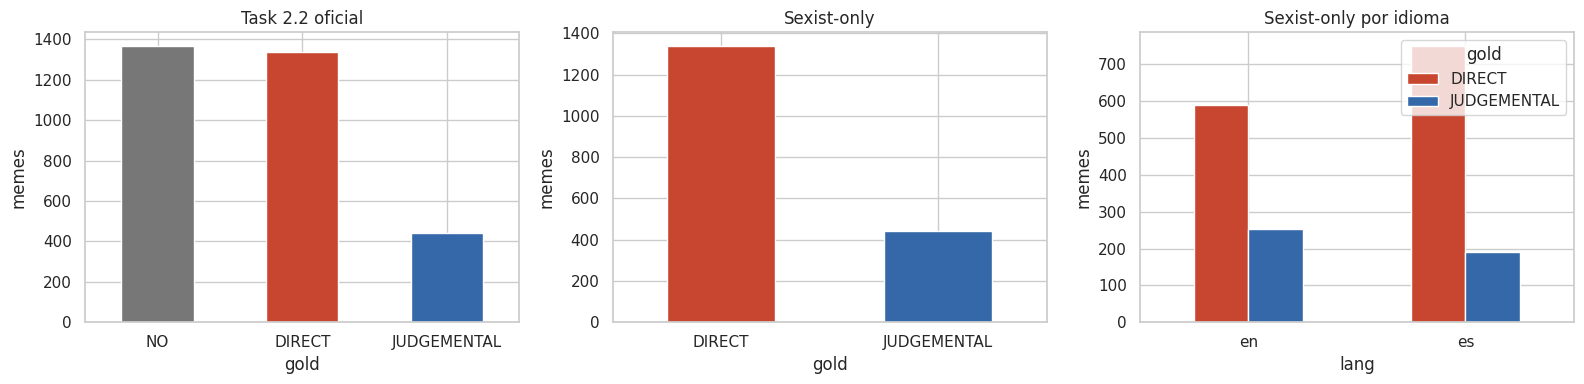

Guardado: /home/sortmon/LNR_CHG/EXIST2026_MEMES_ONLY_FINAL/outputs/tables/task2_2_sexist_only_eda_internal_split.csv


gold,internal_split,lang,DIRECT,JUDGEMENTAL,n
0,fit,en,471,202,673
1,fit,es,599,153,752
2,internal_dev,en,118,51,169
3,internal_dev,es,150,38,188


Guardado: /home/sortmon/LNR_CHG/EXIST2026_MEMES_ONLY_FINAL/outputs/figures/task2_2_sexist_only_eda/02_split_interno.png


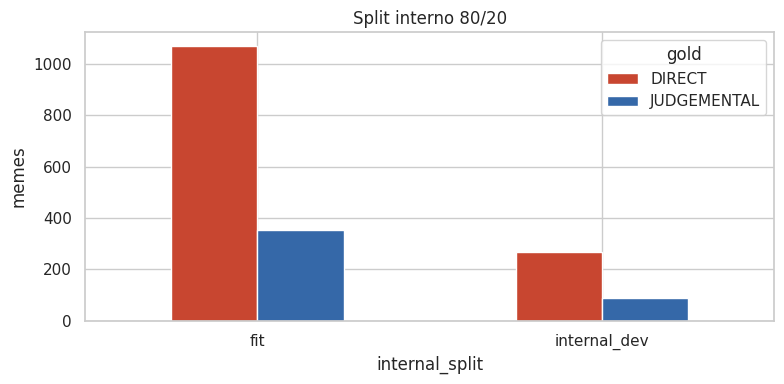

In [3]:
balance_rows = []
for part_name, frame in [
    ("official_task2_2", official_task22),
    ("sexist_only", sexist_df),
    ("fit", fit_df),
    ("internal_dev", internal_dev_df),
]:
    counts = frame["gold"].value_counts().to_dict()
    row = {"part": part_name, "n": len(frame)}
    for label in ["NO", "DIRECT", "JUDGEMENTAL"]:
        row[label] = int(counts.get(label, 0))
    row["direct_share"] = row["DIRECT"] / len(frame) if len(frame) else 0
    row["judgemental_share"] = row["JUDGEMENTAL"] / len(frame) if len(frame) else 0
    balance_rows.append(row)
balance = save_table(pd.DataFrame(balance_rows), "task2_2_sexist_only_eda_balance.csv")
display(balance)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
official_task22["gold"].value_counts().reindex(["NO", "DIRECT", "JUDGEMENTAL"]).plot(
    kind="bar", ax=axes[0], color=[palette["NO"], palette["DIRECT"], palette["JUDGEMENTAL"]]
)
axes[0].set_title("Task 2.2 oficial")
axes[0].set_ylabel("memes")

sexist_df["gold"].value_counts().reindex(LABELS_BIN).plot(
    kind="bar", ax=axes[1], color=[palette["DIRECT"], palette["JUDGEMENTAL"]]
)
axes[1].set_title("Sexist-only")
axes[1].set_ylabel("memes")

lang_label = pd.crosstab(sexist_df["lang"], sexist_df["gold"]).reindex(columns=LABELS_BIN)
lang_label.plot(kind="bar", ax=axes[2], color=[palette["DIRECT"], palette["JUDGEMENTAL"]])
axes[2].set_title("Sexist-only por idioma")
axes[2].set_ylabel("memes")
for ax in axes:
    ax.tick_params(axis="x", rotation=0)
savefig("01_balance_clases_idioma.png")
plt.show()

split_frame = pd.concat([
    fit_df.assign(internal_split="fit"),
    internal_dev_df.assign(internal_split="internal_dev"),
], ignore_index=True)
split_table = pd.crosstab([split_frame["internal_split"], split_frame["lang"]], split_frame["gold"]).reindex(columns=LABELS_BIN).reset_index()
split_table["n"] = split_table[LABELS_BIN].sum(axis=1)
save_table(split_table, "task2_2_sexist_only_eda_internal_split.csv")
display(split_table)

fig, ax = plt.subplots(figsize=(8, 4))
pd.crosstab(split_frame["internal_split"], split_frame["gold"]).reindex(columns=LABELS_BIN).plot(
    kind="bar", ax=ax, color=[palette["DIRECT"], palette["JUDGEMENTAL"]]
)
ax.set_title("Split interno 80/20")
ax.set_ylabel("memes")
ax.tick_params(axis="x", rotation=0)
savefig("02_split_interno.png")
plt.show()

## 3. OCR text: length, noise, and lexical signals

Meme OCR is short, noisy, and rich in web artefacts. This section checks whether `JUDGEMENTAL` differs in length, language, capitalization, URLs, hashtags, or vocabulary.

Guardado: /home/sortmon/LNR_CHG/EXIST2026_MEMES_ONLY_FINAL/outputs/tables/task2_2_sexist_only_eda_text_stats.csv


lang         gold       chars                         words         \
                           mean median         std       mean median   
0   en       DIRECT  113.977929   92.0   91.348372  21.254669   17.0   
1   en  JUDGEMENTAL  126.735178   98.0  129.053626  23.490119   19.0   
2   es       DIRECT  139.507343  100.0  126.734359  24.506008   18.0   
3   es  JUDGEMENTAL  161.178010  125.0  125.030311  27.879581   21.0   

             uppercase_ratio            ... has_hashtag has_mention         \
         std            mean    median  ...         std        mean median   
0  16.473221        0.463213  0.388060  ...    0.108459    0.056027    0.0   
1  21.997044        0.428881  0.272727  ...    0.108460    0.043478    0.0   
2  22.306902        0.428040  0.280702  ...    0.161320    0.096128    0.0   
3  22.107421        0.486089  0.465909  ...    0.188393    0.052356    0.0   

            exclamations                  questions                   
        std         mean median       std      mean median       std  
0  0.230170     0.363328    0.0  1.574806  0.230900    0.0  0.595616  
1  0.204335     0.367589    0.0  1.162943  0.245059    0.0  0.586915  
2  0.294964     0.460614    0.0  1.244285  0.312417    0.0  0.790057  
3  0.223329     0.712042    0.0  1.842713  0.439791    0.0  0.981560  

[4 rows x 32 columns]

Guardado: /home/sortmon/LNR_CHG/EXIST2026_MEMES_ONLY_FINAL/outputs/figures/task2_2_sexist_only_eda/03_text_length_noise.png


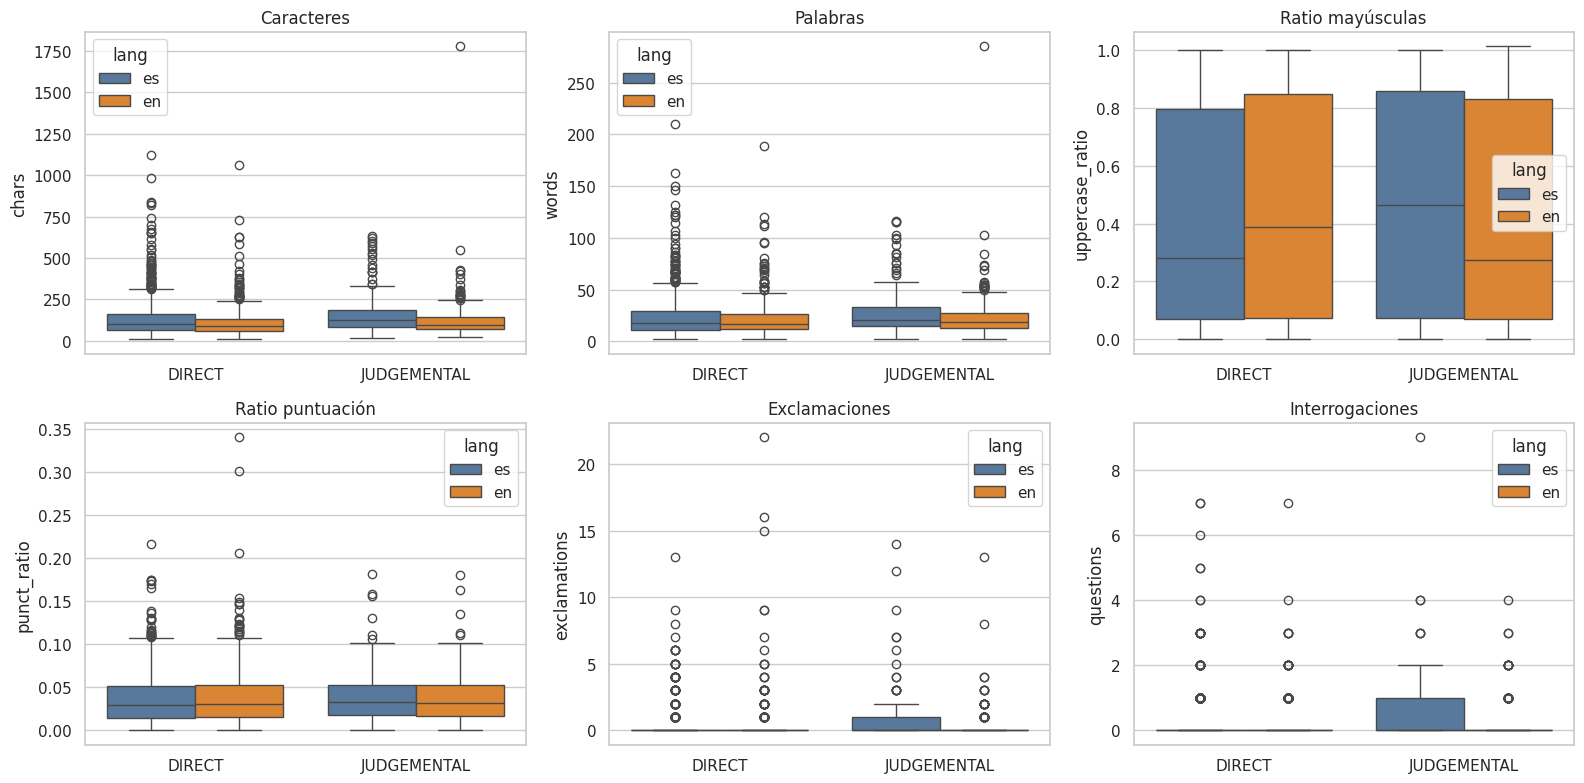

In [4]:
def text_stats(frame):
    out = frame[["id", "lang", "gold", "text"]].copy()
    txt = out["text"].fillna("").astype(str)
    out["chars"] = txt.str.len()
    out["words"] = txt.str.findall(r"\b\w+\b").str.len()
    out["uppercase_ratio"] = txt.apply(lambda s: sum(ch.isupper() for ch in s) / max(sum(ch.isalpha() for ch in s), 1))
    out["digit_ratio"] = txt.apply(lambda s: sum(ch.isdigit() for ch in s) / max(len(s), 1))
    out["punct_ratio"] = txt.apply(lambda s: sum((not ch.isalnum()) and (not ch.isspace()) for ch in s) / max(len(s), 1))
    out["has_url"] = txt.str.contains(r"https?://|www\.|\.com\b", case=False, regex=True).astype(int)
    out["has_hashtag"] = txt.str.contains(r"#\w+", regex=True).astype(int)
    out["has_mention"] = txt.str.contains(r"@\w+", regex=True).astype(int)
    out["exclamations"] = txt.str.count("!")
    out["questions"] = txt.str.count(r"\?")
    return out

text_eda = text_stats(sexist_df)
text_summary = text_eda.groupby(["lang", "gold"])[["chars", "words", "uppercase_ratio", "digit_ratio", "punct_ratio", "has_url", "has_hashtag", "has_mention", "exclamations", "questions"]].agg(["mean", "median", "std"]).reset_index()
save_table(text_summary, "task2_2_sexist_only_eda_text_stats.csv")
display(text_summary)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col, title in zip(
    axes.ravel(),
    ["chars", "words", "uppercase_ratio", "punct_ratio", "exclamations", "questions"],
    ["Caracteres", "Palabras", "Ratio mayúsculas", "Ratio puntuación", "Exclamaciones", "Interrogaciones"],
):
    sns.boxplot(data=text_eda, x="gold", y=col, hue="lang", ax=ax, palette=[palette["en"], palette["es"]])
    ax.set_title(title)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
savefig("03_text_length_noise.png")
plt.show()

Guardado: /home/sortmon/LNR_CHG/EXIST2026_MEMES_ONLY_FINAL/outputs/tables/task2_2_sexist_only_eda_top_unigrams.csv


Guardado: /home/sortmon/LNR_CHG/EXIST2026_MEMES_ONLY_FINAL/outputs/tables/task2_2_sexist_only_eda_top_bigrams.csv


,label,rank,ngram,count,ngram_size
0,DIRECT,1,es,1031,1
1,DIRECT,2,en,831,1
2,DIRECT,3,de,574,1
3,DIRECT,4,que,555,1
4,DIRECT,5,la,428,1
5,DIRECT,6,no,421,1
6,DIRECT,7,el,335,1
7,DIRECT,8,me,314,1
8,DIRECT,9,the,289,1
9,DIRECT,10,you,278,1


,label,rank,ngram,count,ngram_size
0,DIRECT,1,imgflip com,86,2
1,DIRECT,2,memegenerator es,71,2
2,DIRECT,3,las mujeres,70,2
3,DIRECT,4,de la,69,2
4,DIRECT,5,ifunny co,55,2
5,DIRECT,6,makeameme org,55,2
6,DIRECT,7,en when,52,2
7,DIRECT,8,que no,44,2
8,DIRECT,9,es cuando,43,2
9,DIRECT,10,una mujer,38,2


Guardado: /home/sortmon/LNR_CHG/EXIST2026_MEMES_ONLY_FINAL/outputs/figures/task2_2_sexist_only_eda/04_top_tokens_por_clase.png


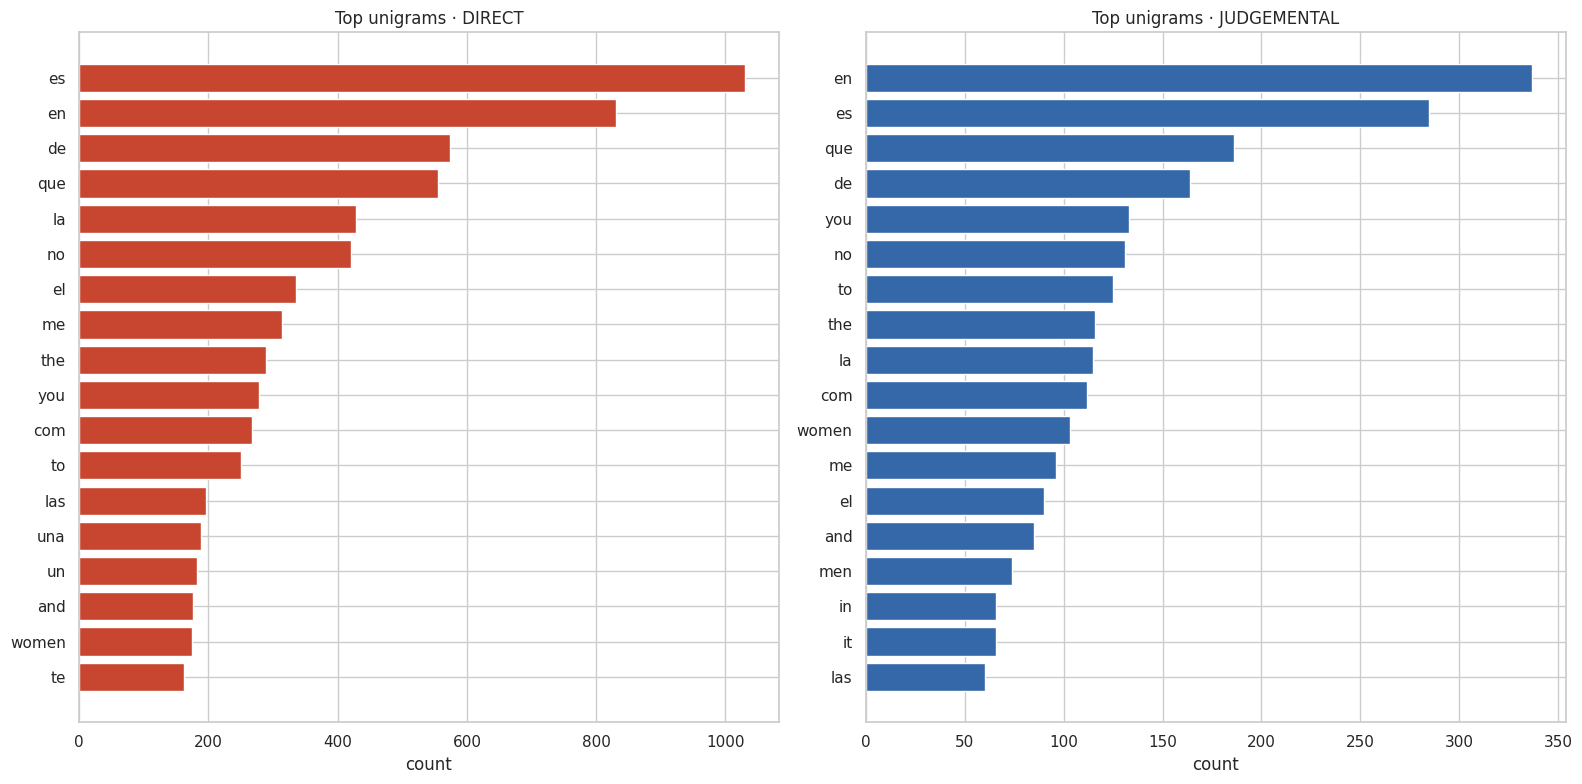

Guardado: /home/sortmon/LNR_CHG/EXIST2026_MEMES_ONLY_FINAL/outputs/tables/task2_2_sexist_only_eda_text_chi2_features.csv


,term,chi2,p_value,mean_direct,mean_judgemental,leans_to,mean_diff
2815,isn,4.040062,0.044432,0.000000,0.003019,JUDGEMENTAL,-0.003019
179,according,3.740920,0.053095,0.000000,0.002796,JUDGEMENTAL,-0.002796
180,according to,3.740920,0.053095,0.000000,0.002796,JUDGEMENTAL,-0.002796
4949,siendo,3.547651,0.059630,0.000060,0.002935,JUDGEMENTAL,-0.002875
591,body,3.142196,0.076291,0.000396,0.003830,JUDGEMENTAL,-0.003434
4019,oppressed,3.059012,0.080290,0.000000,0.002286,JUDGEMENTAL,-0.002286
3932,objectify me,2.996781,0.083430,0.000000,0.002240,JUDGEMENTAL,-0.002240
507,be like,2.934599,0.086700,0.002068,0.007569,JUDGEMENTAL,-0.005502
3569,misogynistic,2.864696,0.090543,0.000000,0.002141,JUDGEMENTAL,-0.002141
3477,mend,2.811280,0.093604,0.000000,0.002101,JUDGEMENTAL,-0.002101


Guardado: /home/sortmon/LNR_CHG/EXIST2026_MEMES_ONLY_FINAL/outputs/figures/task2_2_sexist_only_eda/05_text_chi2_features.png


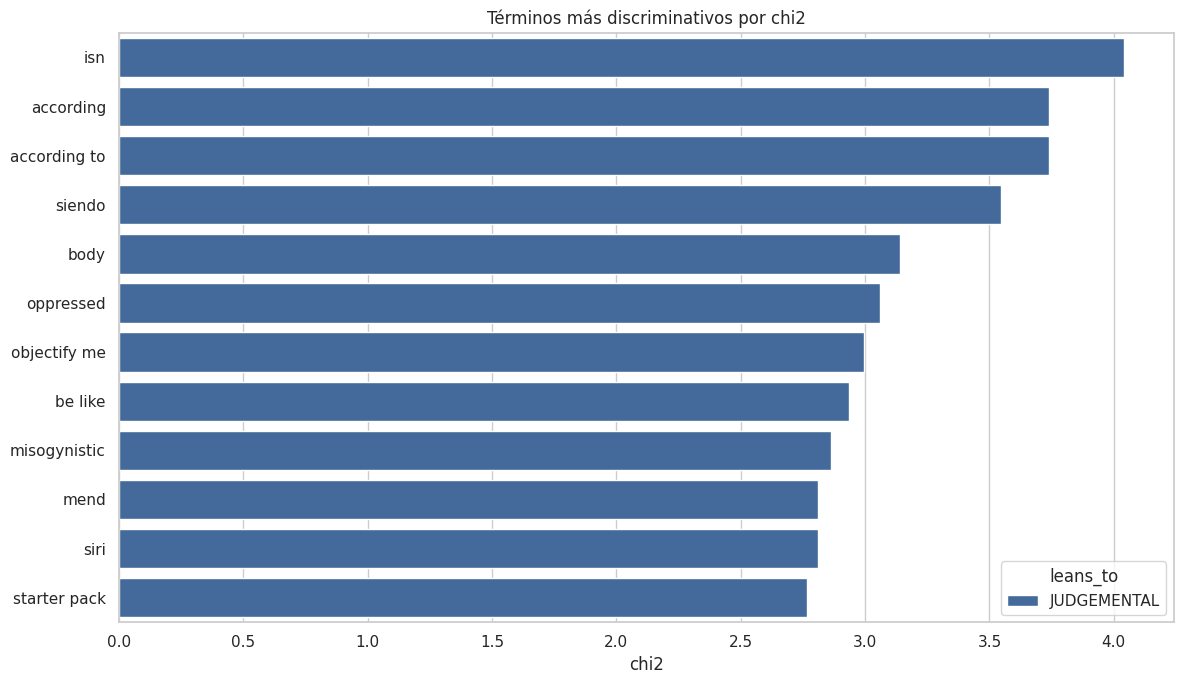

In [5]:
def top_ngrams(frame, ngram_range=(1, 1), top_n=25, min_df=2):
    rows = []
    for label in LABELS_BIN:
        vec = CountVectorizer(lowercase=True, strip_accents="unicode", token_pattern=r"(?u)\b\w\w+\b", ngram_range=ngram_range, min_df=min_df)
        matrix = vec.fit_transform(text_inputs(frame[frame["gold"] == label]))
        counts = np.asarray(matrix.sum(axis=0)).ravel()
        vocab = np.asarray(vec.get_feature_names_out())
        order = counts.argsort()[::-1][:top_n]
        for rank, idx in enumerate(order, start=1):
            rows.append({"label": label, "rank": rank, "ngram": vocab[idx], "count": int(counts[idx]), "ngram_size": ngram_range[1]})
    return pd.DataFrame(rows)

top_unigrams = save_table(top_ngrams(sexist_df, (1, 1), top_n=30), "task2_2_sexist_only_eda_top_unigrams.csv")
top_bigrams = save_table(top_ngrams(sexist_df, (2, 2), top_n=30), "task2_2_sexist_only_eda_top_bigrams.csv")
display(top_unigrams.head(12))
display(top_bigrams.head(12))

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, label in zip(axes, LABELS_BIN):
    data = top_unigrams[top_unigrams["label"] == label].head(18).iloc[::-1]
    ax.barh(data["ngram"], data["count"], color=palette[label])
    ax.set_title(f"Top unigrams · {label}")
    ax.set_xlabel("count")
savefig("04_top_tokens_por_clase.png")
plt.show()

# Señales discriminativas supervisadas solo para orientar hipótesis, no para validar modelos.
y_binary = (sexist_df["gold"].astype(str) == "DIRECT").astype(int).to_numpy()
vec = TfidfVectorizer(lowercase=True, strip_accents="unicode", ngram_range=(1, 2), min_df=2, max_features=80000, sublinear_tf=True)
X = vec.fit_transform(text_inputs(sexist_df))
chi, pvals = chi2(X, y_binary)
terms = np.asarray(vec.get_feature_names_out())
mean_direct = np.asarray(X[y_binary == 1].mean(axis=0)).ravel()
mean_judg = np.asarray(X[y_binary == 0].mean(axis=0)).ravel()
chi_df = pd.DataFrame({
    "term": terms,
    "chi2": chi,
    "p_value": pvals,
    "mean_direct": mean_direct,
    "mean_judgemental": mean_judg,
    "leans_to": np.where(mean_direct >= mean_judg, "DIRECT", "JUDGEMENTAL"),
    "mean_diff": mean_direct - mean_judg,
}).sort_values("chi2", ascending=False).head(80)
save_table(chi_df, "task2_2_sexist_only_eda_text_chi2_features.csv")
display(chi_df.head(20))

plot_chi = pd.concat([
    chi_df[chi_df["leans_to"] == "DIRECT"].head(12),
    chi_df[chi_df["leans_to"] == "JUDGEMENTAL"].head(12),
])
fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(data=plot_chi, y="term", x="chi2", hue="leans_to", dodge=False, palette={"DIRECT": palette["DIRECT"], "JUDGEMENTAL": palette["JUDGEMENTAL"]}, ax=ax)
ax.set_title("Términos más discriminativos por chi2")
ax.set_ylabel("")
savefig("05_text_chi2_features.png")
plt.show()

## 4. Soft labels and annotator disagreement

Soft labels expose ambiguous examples. Lower margins or higher entropy for `JUDGEMENTAL` would indicate a genuinely uncertain class boundary rather than only a modelling failure.

Guardado: /home/sortmon/LNR_CHG/EXIST2026_MEMES_ONLY_FINAL/outputs/tables/task2_2_sexist_only_eda_soft_labels.csv


lang         gold  p_DIRECT                     p_JUDGEMENTAL            \
                         mean    median       std          mean    median   
0   en       DIRECT  0.658319  0.666667  0.150379      0.190719  0.166667   
1   en  JUDGEMENTAL  0.259684  0.333333  0.134615      0.566535  0.500000   
2   es       DIRECT  0.693947  0.666667  0.164637      0.154473  0.166667   
3   es  JUDGEMENTAL  0.232286  0.166667  0.133241      0.593019  0.500000   

                 p_NO                     soft_entropy                      \
        std      mean    median       std         mean    median       std   
0  0.133661  0.150962  0.166667  0.128259     1.044633  1.000000  0.407461   
1  0.099270  0.173781  0.166667  0.125013     1.243709  1.459148  0.270033   
2  0.134784  0.151580  0.166667  0.128138     0.953095  0.918296  0.459793   
3  0.119688  0.174695  0.166667  0.118837     1.207610  1.251629  0.308705   

  soft_margin_direct_judgemental                      
                            mean    median       std  
0                       0.467600  0.500000  0.253985  
1                       0.306851  0.333333  0.200806  
2                       0.539475  0.500000  0.272258  
3                       0.360733  0.333333  0.223685

Guardado: /home/sortmon/LNR_CHG/EXIST2026_MEMES_ONLY_FINAL/outputs/figures/task2_2_sexist_only_eda/06_soft_labels_disagreement.png


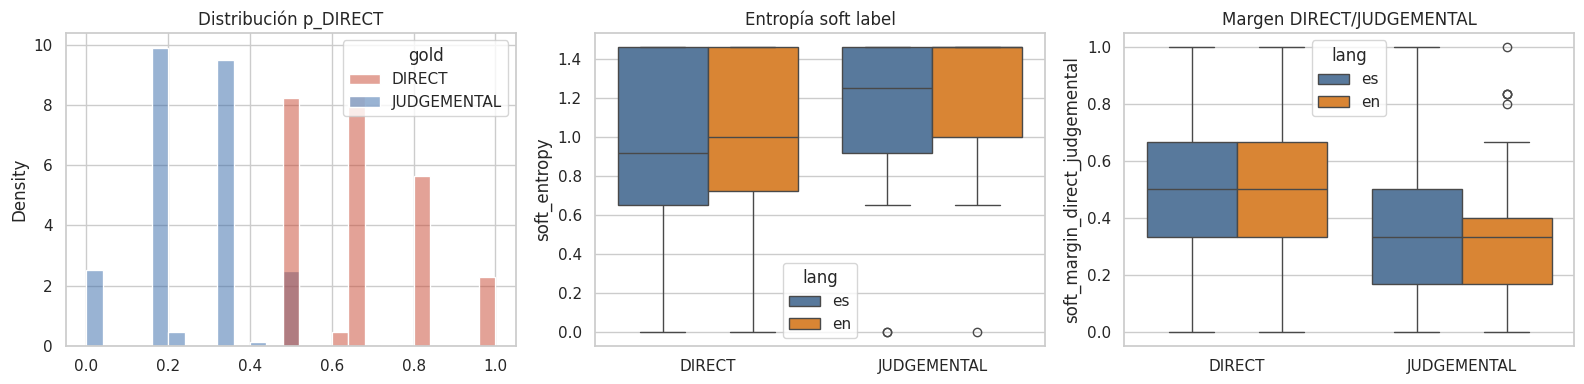

Guardado: /home/sortmon/LNR_CHG/EXIST2026_MEMES_ONLY_FINAL/outputs/tables/task2_2_sexist_only_eda_most_ambiguous.csv


,id,lang,gold,p_DIRECT,p_JUDGEMENTAL,p_NO,soft_entropy,soft_margin_direct_judgemental,soft_winner
64,110098,es,DIRECT,0.5,0.5,0.0,1.0,0.0,DIRECT
95,110166,es,DIRECT,0.5,0.5,0.0,1.0,0.0,DIRECT
97,110168,es,JUDGEMENTAL,0.5,0.5,0.0,1.0,0.0,DIRECT
103,110177,es,DIRECT,0.5,0.5,0.0,1.0,0.0,DIRECT
141,110286,es,JUDGEMENTAL,0.5,0.5,0.0,1.0,0.0,DIRECT
155,110324,es,DIRECT,0.5,0.5,0.0,1.0,0.0,DIRECT
162,110340,es,JUDGEMENTAL,0.5,0.5,0.0,1.0,0.0,DIRECT
194,110422,es,DIRECT,0.5,0.5,0.0,1.0,0.0,DIRECT
195,110426,es,DIRECT,0.5,0.5,0.0,1.0,0.0,DIRECT
335,110717,es,DIRECT,0.5,0.5,0.0,1.0,0.0,DIRECT


In [6]:
soft_rows = []
for row in sexist_df.itertuples():
    soft = row.soft_gold if isinstance(row.soft_gold, dict) else {}
    p_direct = float(soft.get("DIRECT", 0.0))
    p_judgemental = float(soft.get("JUDGEMENTAL", 0.0))
    p_no = float(soft.get("NO", 0.0))
    arr = np.asarray([p_direct, p_judgemental, p_no], dtype=float)
    if arr.sum() > 0:
        arr = arr / arr.sum()
    soft_rows.append({
        "id": str(row.id),
        "lang": row.lang,
        "gold": row.gold,
        "p_DIRECT": p_direct,
        "p_JUDGEMENTAL": p_judgemental,
        "p_NO": p_no,
        "soft_entropy": float(entropy(np.clip(arr, 1e-12, 1.0), base=2)),
        "soft_margin_direct_judgemental": abs(p_direct - p_judgemental),
        "soft_winner": "DIRECT" if p_direct >= p_judgemental else "JUDGEMENTAL",
    })
soft_df = pd.DataFrame(soft_rows)
soft_summary = soft_df.groupby(["lang", "gold"])[["p_DIRECT", "p_JUDGEMENTAL", "p_NO", "soft_entropy", "soft_margin_direct_judgemental"]].agg(["mean", "median", "std"]).reset_index()
save_table(soft_summary, "task2_2_sexist_only_eda_soft_labels.csv")
display(soft_summary)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(data=soft_df, x="p_DIRECT", hue="gold", bins=25, common_norm=False, stat="density", palette={"DIRECT": palette["DIRECT"], "JUDGEMENTAL": palette["JUDGEMENTAL"]}, ax=axes[0])
axes[0].set_title("Distribución p_DIRECT")
sns.boxplot(data=soft_df, x="gold", y="soft_entropy", hue="lang", palette=[palette["en"], palette["es"]], ax=axes[1])
axes[1].set_title("Entropía soft label")
sns.boxplot(data=soft_df, x="gold", y="soft_margin_direct_judgemental", hue="lang", palette=[palette["en"], palette["es"]], ax=axes[2])
axes[2].set_title("Margen DIRECT/JUDGEMENTAL")
for ax in axes:
    ax.set_xlabel("")
savefig("06_soft_labels_disagreement.png")
plt.show()

ambiguous = soft_df.sort_values(["soft_margin_direct_judgemental", "soft_entropy"], ascending=[True, False]).head(30)
save_table(ambiguous, "task2_2_sexist_only_eda_most_ambiguous.csv")
display(ambiguous.head(10))

## 5. Image descriptors and examples

In addition to CLIP features used downstream, the feature frame contains handcrafted visual descriptors (`vis_*`) covering colour, brightness, edges, texture, orientation, and image regions. This section checks for systematic class differences.

Guardado: /home/sortmon/LNR_CHG/EXIST2026_MEMES_ONLY_FINAL/outputs/tables/task2_2_sexist_only_eda_visual_effect_sizes.csv
N columnas visuales: 193


,feature,direct_mean,judgemental_mean,cohen_d_direct_minus_judgemental,abs_d,missing_rate
0,vis_orientation_hist_08,0.082473,0.086247,-0.182498,0.182498,0.0
1,vis_grid_22_edge_mean,0.063899,0.069080,-0.159054,0.159054,0.0
2,vis_hsv_h_hist_02,0.036874,0.027254,0.139830,0.139830,0.0
3,vis_hsv_s_hist_01,0.134025,0.120069,0.128533,0.128533,0.0
4,vis_b_hist_03,0.110575,0.101513,0.128496,0.128496,0.0
5,vis_orientation_hist_02,0.086647,0.089153,-0.124050,0.124050,0.0
6,vis_b_hist_02,0.121858,0.112162,0.118724,0.118724,0.0
7,vis_edge_density_010,0.242695,0.252444,-0.115089,0.115089,0.0
8,vis_orientation_hist_06,0.106652,0.103044,0.114760,0.114760,0.0
9,vis_orientation_hist_09,0.105730,0.109320,-0.111047,0.111047,0.0


Guardado: /home/sortmon/LNR_CHG/EXIST2026_MEMES_ONLY_FINAL/outputs/figures/task2_2_sexist_only_eda/07_visual_top_features.png


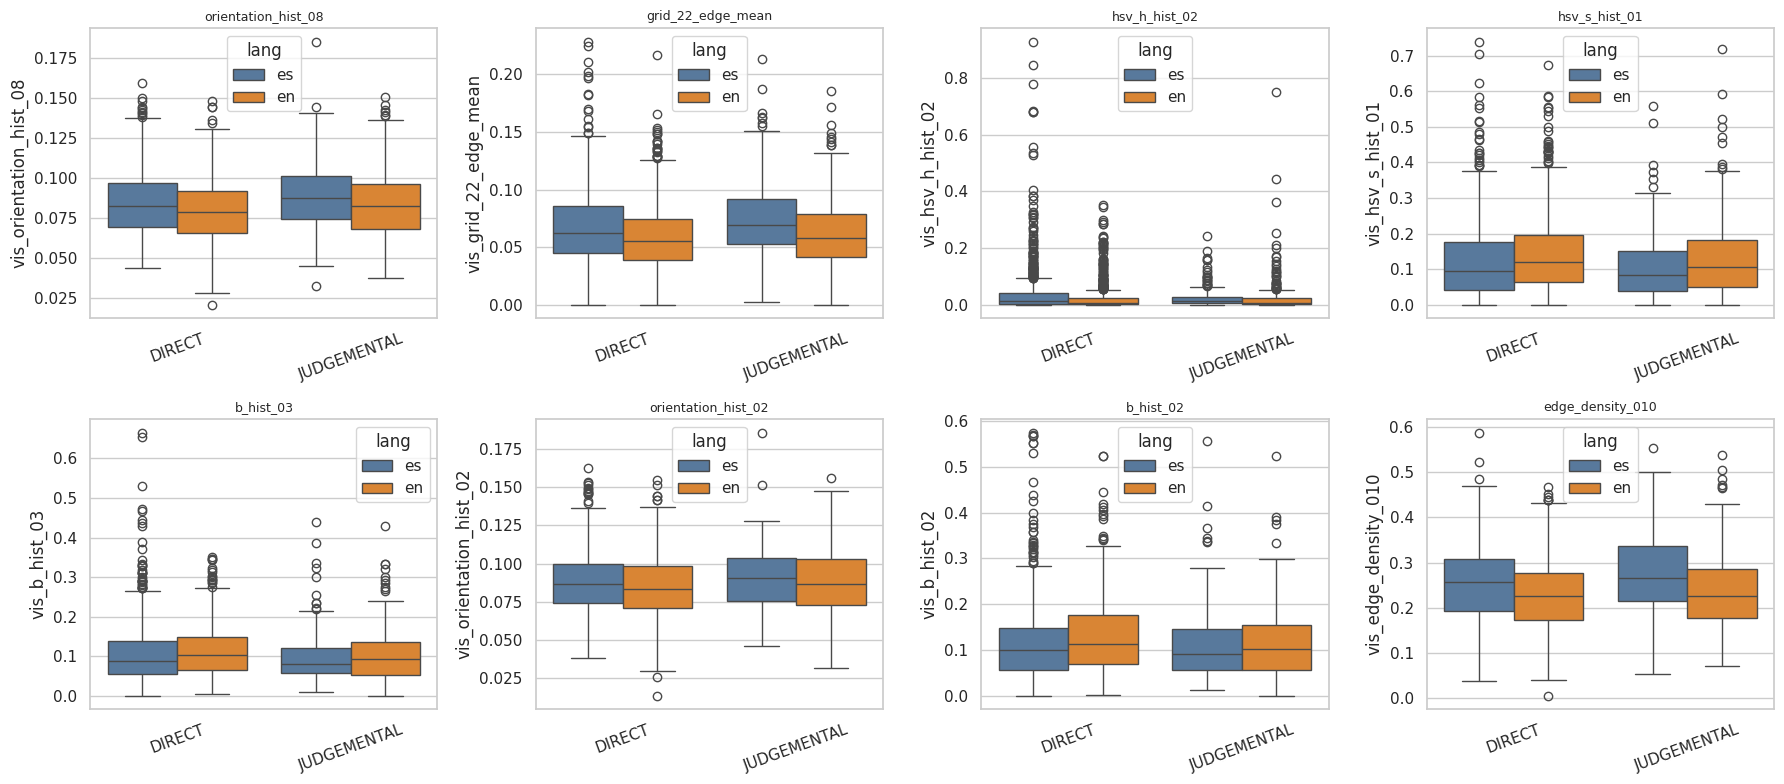

Guardado: /home/sortmon/LNR_CHG/EXIST2026_MEMES_ONLY_FINAL/outputs/figures/task2_2_sexist_only_eda/08_visual_pca.png


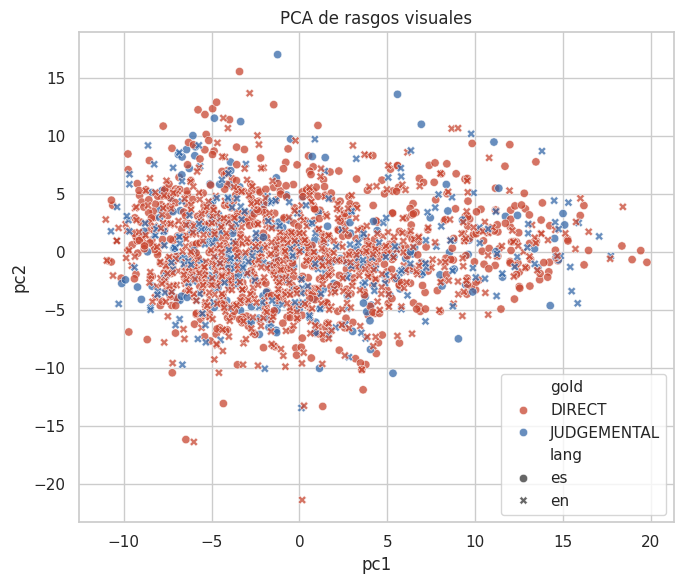

In [7]:
def numeric_cols(frame, prefixes):
    prefixes = tuple(prefixes)
    return [col for col in frame.columns if col.startswith(prefixes) and pd.api.types.is_numeric_dtype(frame[col])]


def effect_size_table(frame, columns, group_col="gold"):
    rows = []
    for col in columns:
        a = pd.to_numeric(frame.loc[frame[group_col] == "DIRECT", col], errors="coerce").dropna().to_numpy(dtype=float)
        b = pd.to_numeric(frame.loc[frame[group_col] == "JUDGEMENTAL", col], errors="coerce").dropna().to_numpy(dtype=float)
        if len(a) < 5 or len(b) < 5:
            continue
        pooled = math.sqrt((np.nanvar(a) + np.nanvar(b)) / 2.0)
        d = 0.0 if pooled == 0 else (np.nanmean(a) - np.nanmean(b)) / pooled
        rows.append({
            "feature": col,
            "direct_mean": float(np.nanmean(a)),
            "judgemental_mean": float(np.nanmean(b)),
            "cohen_d_direct_minus_judgemental": float(d),
            "abs_d": abs(float(d)),
            "missing_rate": float(frame[col].isna().mean()),
        })
    return pd.DataFrame(rows).sort_values("abs_d", ascending=False).reset_index(drop=True)

vis_cols = numeric_cols(sexist_df, ["vis_"])
visual_effects = save_table(effect_size_table(sexist_df, vis_cols), "task2_2_sexist_only_eda_visual_effect_sizes.csv")
print("N columnas visuales:", len(vis_cols))
display(visual_effects.head(20))

selected_visual = visual_effects.head(8)["feature"].tolist()
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.ravel(), selected_visual):
    sns.boxplot(data=sexist_df, x="gold", y=col, hue="lang", palette=[palette["en"], palette["es"]], ax=ax)
    ax.set_title(col.replace("vis_", ""), fontsize=9)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
savefig("07_visual_top_features.png")
plt.show()

# PCA visual para ver si hay separación global.
if len(vis_cols) >= 2:
    X_vis = SimpleImputer(strategy="median").fit_transform(sexist_df[vis_cols])
    X_vis = StandardScaler().fit_transform(X_vis)
    pcs = PCA(n_components=2, random_state=SEED).fit_transform(X_vis)
    pca_vis = pd.DataFrame({"pc1": pcs[:, 0], "pc2": pcs[:, 1], "gold": sexist_df["gold"], "lang": sexist_df["lang"]})
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.scatterplot(data=pca_vis, x="pc1", y="pc2", hue="gold", style="lang", palette={"DIRECT": palette["DIRECT"], "JUDGEMENTAL": palette["JUDGEMENTAL"]}, alpha=0.75, ax=ax)
    ax.set_title("PCA de rasgos visuales")
    savefig("08_visual_pca.png")
    plt.show()

Guardado: /home/sortmon/LNR_CHG/EXIST2026_MEMES_ONLY_FINAL/outputs/figures/task2_2_sexist_only_eda/09_sample_memes_ambiguous.png


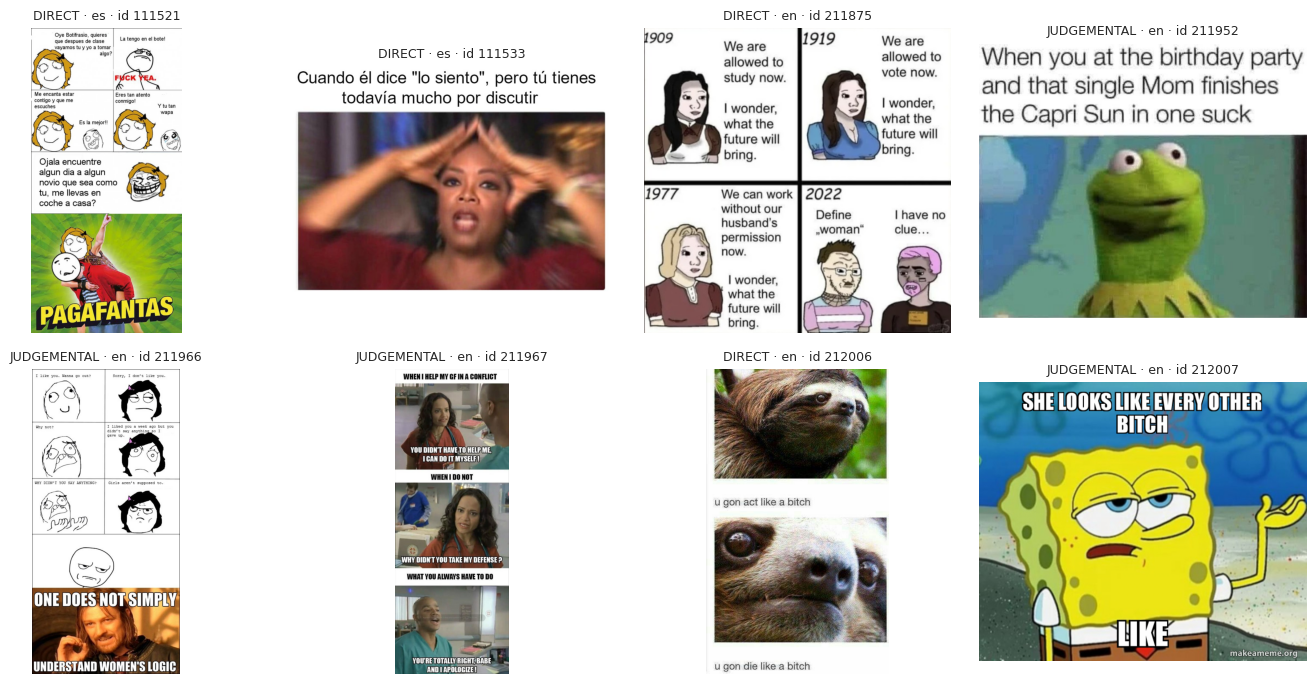

In [8]:
# Galería pequeña de ejemplos ambiguos/representativos para inspección manual.
sample_ids = []
for label in LABELS_BIN:
    sample_ids.extend(soft_df[soft_df["gold"] == label].sort_values("soft_margin_direct_judgemental").head(4)["id"].tolist())
gallery = sexist_df[sexist_df["id"].astype(str).isin(sample_ids)].copy().head(8)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, row in zip(axes.ravel(), gallery.itertuples()):
    try:
        with Image.open(row.image_path) as img:
            img = ImageOps.exif_transpose(img).convert("RGB")
            ax.imshow(img)
    except Exception:
        ax.text(0.5, 0.5, "imagen no disponible", ha="center", va="center")
    ax.set_title(f"{row.gold} · {row.lang} · id {row.id}", fontsize=9)
    ax.axis("off")
for ax in axes.ravel()[len(gallery):]:
    ax.axis("off")
savefig("09_sample_memes_ambiguous.png")
plt.show()

## 6. Physiological sensors: coverage, modalities, and signal

The sensor audit covers three modalities:

- `ET`: eye tracking, including fixations, saccades, blinks, and pupil measurements.
- `HR`: heart-rate measurements.
- `EEG`: band and channel statistics.

The objective is to assess both coverage and whether the observed differences between `DIRECT` and `JUDGEMENTAL` are stable enough to support modelling.

Guardado: /home/sortmon/LNR_CHG/EXIST2026_MEMES_ONLY_FINAL/outputs/tables/task2_2_sexist_only_eda_sensor_coverage.csv


,modality,n_features,row_coverage_any_feature,users_mean,users_median,missing_rate_mean
0,ET,49,1.0,2.058361,2.0,0.034014
1,HR,9,1.0,2.061728,2.0,0.000000
2,EEG,289,1.0,2.034231,2.0,0.442907


Guardado: /home/sortmon/LNR_CHG/EXIST2026_MEMES_ONLY_FINAL/outputs/figures/task2_2_sexist_only_eda/10_sensor_coverage.png


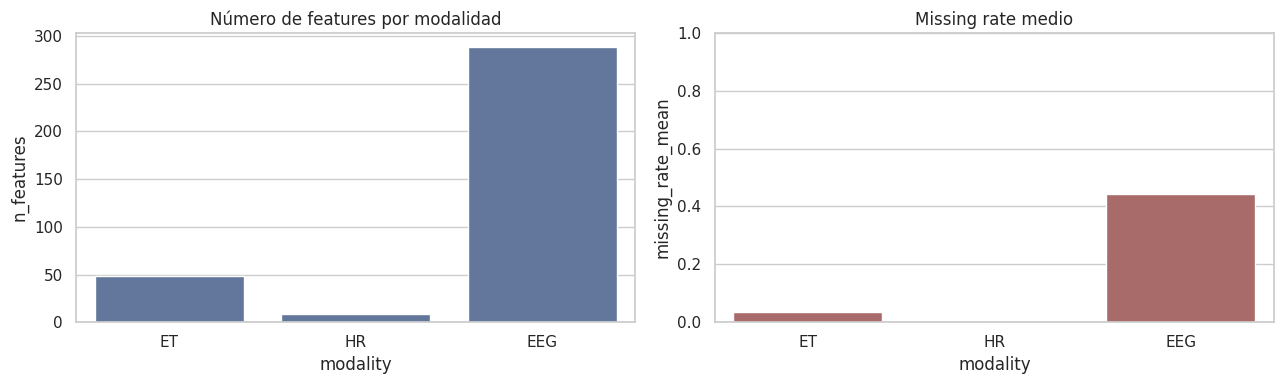

Guardado: /home/sortmon/LNR_CHG/EXIST2026_MEMES_ONLY_FINAL/outputs/tables/task2_2_sexist_only_eda_sensor_users.csv


lang         gold sens_users_count                  sens_ET_users_count  \
                                mean median       std                mean   
0   en       DIRECT         3.945671    4.0  0.226859            2.069610   
1   en  JUDGEMENTAL         3.920949    4.0  0.270354            2.090909   
2   es       DIRECT         3.819760    4.0  0.401647            2.046729   
3   es  JUDGEMENTAL         3.884817    4.0  0.320082            2.026178   

                   sens_HR_users_count                  sens_EEG_users_count  \
  median       std                mean median       std                 mean   
0    2.0  0.254704            2.071307    2.0  0.257556             2.025467   
1    2.0  0.288050            2.090909    2.0  0.288050             2.023715   
2    2.0  0.217437            2.046729    2.0  0.217437             2.045394   
3    2.0  0.160084            2.052356    2.0  0.223329             2.031414   

                    
  median       std  
0    2.0  0.157672  
1    2.0  0.152463  
2    2.0  0.208306  
3    2.0  0.174891

In [9]:
sensor_cols = numeric_cols(sexist_df, ["sens_"])
et_cols = numeric_cols(sexist_df, ["sens_ET_"])
hr_cols = numeric_cols(sexist_df, ["sens_HR_"])
eeg_cols = numeric_cols(sexist_df, ["sens_EEG_"])
modalities = {"ET": et_cols, "HR": hr_cols, "EEG": eeg_cols}

coverage_rows = []
for name, cols in modalities.items():
    users_col = f"sens_{name}_users_count"
    non_missing_any = sexist_df[cols].notna().any(axis=1).mean() if cols else 0.0
    users_mean = float(sexist_df[users_col].mean()) if users_col in sexist_df else np.nan
    users_median = float(sexist_df[users_col].median()) if users_col in sexist_df else np.nan
    coverage_rows.append({
        "modality": name,
        "n_features": len(cols),
        "row_coverage_any_feature": non_missing_any,
        "users_mean": users_mean,
        "users_median": users_median,
        "missing_rate_mean": float(sexist_df[cols].isna().mean().mean()) if cols else np.nan,
    })
coverage = save_table(pd.DataFrame(coverage_rows), "task2_2_sexist_only_eda_sensor_coverage.csv")
display(coverage)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(data=coverage, x="modality", y="n_features", ax=axes[0], color="#5875a4")
axes[0].set_title("Número de features por modalidad")
sns.barplot(data=coverage, x="modality", y="missing_rate_mean", ax=axes[1], color="#b45f5f")
axes[1].set_title("Missing rate medio")
axes[1].set_ylim(0, 1)
savefig("10_sensor_coverage.png")
plt.show()

users_cols = [col for col in ["sens_users_count", "sens_ET_users_count", "sens_HR_users_count", "sens_EEG_users_count"] if col in sexist_df.columns]
users_summary = sexist_df.groupby(["lang", "gold"])[users_cols].agg(["mean", "median", "std"]).reset_index()
save_table(users_summary, "task2_2_sexist_only_eda_sensor_users.csv")
display(users_summary)

Guardado: /home/sortmon/LNR_CHG/EXIST2026_MEMES_ONLY_FINAL/outputs/tables/task2_2_sexist_only_eda_sensor_effect_sizes.csv


,modality,feature,direct_mean,judgemental_mean,cohen_d_direct_minus_judgemental,abs_d,missing_rate
0,ET,sens_ET_saccades_count_mean,4.055313e+01,4.820383e+01,-0.315192,0.315192,0.000000
1,ET,sens_ET_fixations_count_mean,4.137924e+01,4.880582e+01,-0.306628,0.306628,0.000000
2,ET,sens_ET_reaction_time_mean,1.477836e+04,1.719027e+04,-0.300379,0.300379,0.000000
3,ET,sens_ET_fixations_count_std,1.047276e+01,1.433963e+01,-0.272444,0.272444,0.000000
4,ET,sens_ET_saccades_count_std,1.073567e+01,1.434748e+01,-0.255099,0.255099,0.000000
5,ET,sens_ET_reaction_time_std,3.416228e+03,4.528510e+03,-0.229407,0.229407,0.000000
6,ET,sens_ET_blinks_count_mean,2.208953e+00,2.592334e+00,-0.190926,0.190926,0.166667
7,ET,sens_ET_saccades_duration_mean_ns_std,7.737834e+08,1.751641e+08,0.188451,0.188451,0.000000
8,ET,sens_ET_saccades_duration_max_ns_std,1.134254e+09,4.969872e+08,0.187437,0.187437,0.000000
9,ET,sens_ET_saccades_duration_max_ns_mean,1.313711e+09,6.701543e+08,0.186783,0.186783,0.000000


Guardado: /home/sortmon/LNR_CHG/EXIST2026_MEMES_ONLY_FINAL/outputs/figures/task2_2_sexist_only_eda/11_sensor_effect_sizes.png


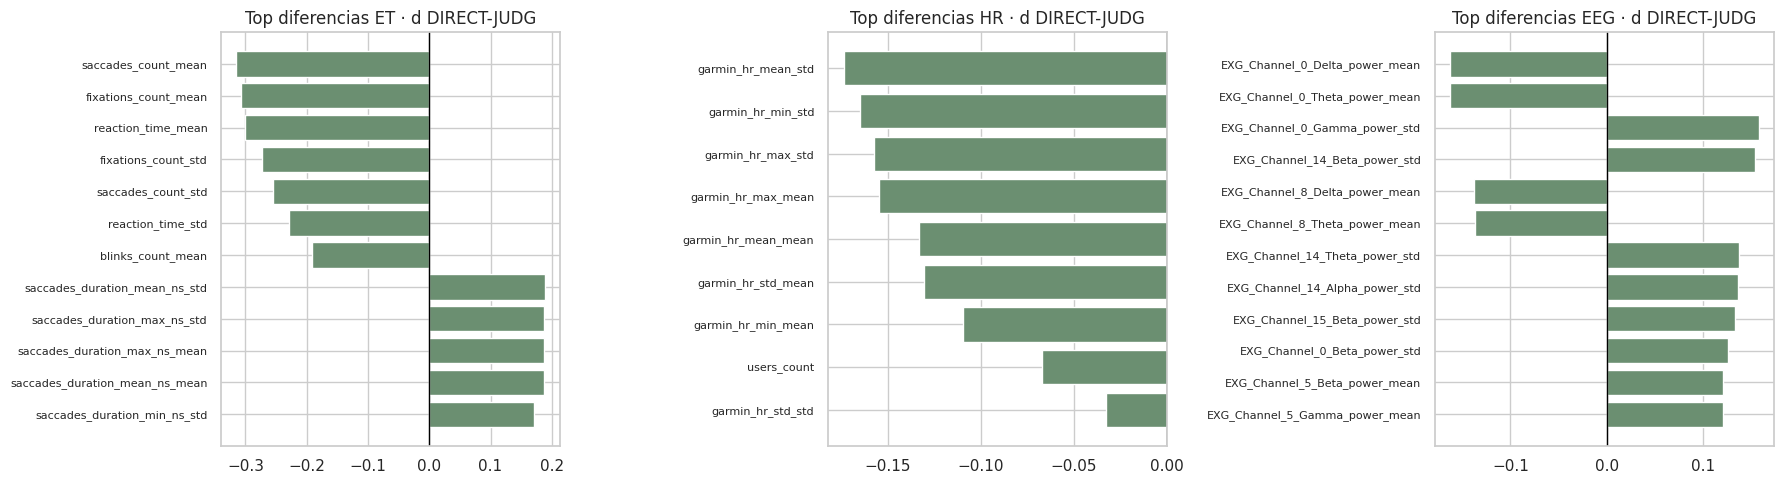

Guardado: /home/sortmon/LNR_CHG/EXIST2026_MEMES_ONLY_FINAL/outputs/figures/task2_2_sexist_only_eda/12_sensor_top_feature_distributions.png


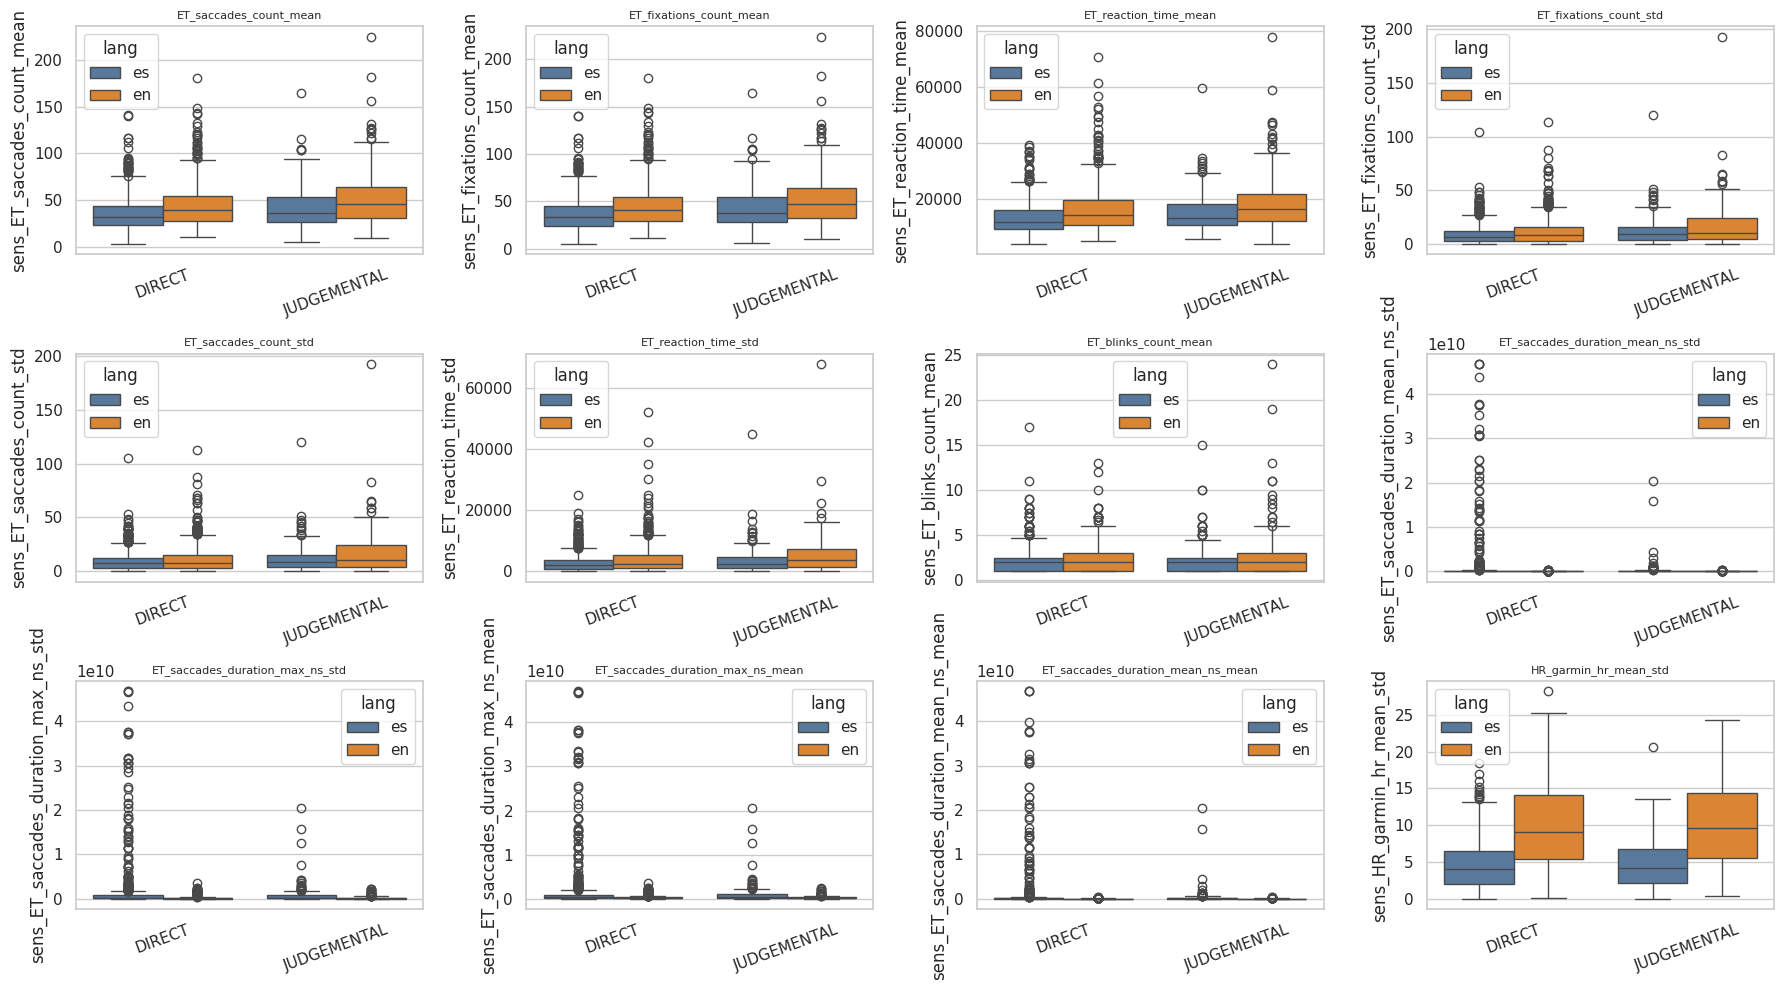

In [10]:
sensor_effects = []
for modality, cols in modalities.items():
    if not cols:
        continue
    tmp = effect_size_table(sexist_df, cols)
    tmp.insert(0, "modality", modality)
    sensor_effects.append(tmp)
sensor_effects = pd.concat(sensor_effects, ignore_index=True).sort_values("abs_d", ascending=False).reset_index(drop=True)
save_table(sensor_effects, "task2_2_sexist_only_eda_sensor_effect_sizes.csv")
display(sensor_effects.head(30))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, modality in zip(axes, ["ET", "HR", "EEG"]):
    data = sensor_effects[sensor_effects["modality"] == modality].head(12).iloc[::-1]
    ax.barh(data["feature"].str.replace(f"sens_{modality}_", "", regex=False), data["cohen_d_direct_minus_judgemental"], color="#6b8f71")
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(f"Top diferencias {modality} · d DIRECT-JUDG")
    ax.tick_params(axis="y", labelsize=8)
savefig("11_sensor_effect_sizes.png")
plt.show()

selected_sensor = sensor_effects.head(12)["feature"].tolist()
fig, axes = plt.subplots(3, 4, figsize=(18, 10))
for ax, col in zip(axes.ravel(), selected_sensor):
    sns.boxplot(data=sexist_df, x="gold", y=col, hue="lang", palette=[palette["en"], palette["es"]], ax=ax)
    ax.set_title(col.replace("sens_", ""), fontsize=8)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
savefig("12_sensor_top_feature_distributions.png")
plt.show()

### 6.1. Paper-guided sensor analysis

The analysis separates interpretable physiological axes rather than treating sensors as one undifferentiated matrix: reaction time, fixations, saccades, blinks, pupil diameter, heart rate, and EEG bands. It also audits whether baseline columns such as `baseline_prev` or `baseline_prev5` exist in this data release, avoiding unsupported assumptions about normalization.

Guardado: /home/sortmon/LNR_CHG/EXIST2026_MEMES_ONLY_FINAL/outputs/tables/task2_2_sexist_only_eda_paper_sensor_axis_summary.csv


,gold,axis,family,unit,n,mean,median,std
0,NO,ET · duración fijación,ET_fixations,ms,1367,273.836703,276.264490,66.145057
1,DIRECT,ET · duración fijación,ET_fixations,ms,1338,289.407568,286.866453,78.209451
2,JUDGEMENTAL,ET · duración fijación,ET_fixations,ms,444,290.401435,290.705158,73.726377
3,NO,ET · duración parpadeo,ET_blinks,ms,1098,265.950780,262.762928,50.260401
4,DIRECT,ET · duración parpadeo,ET_blinks,ms,1116,258.544758,255.253632,46.370300
5,JUDGEMENTAL,ET · duración parpadeo,ET_blinks,ms,369,259.858497,258.584320,40.846680
6,NO,ET · fijaciones,ET_fixations,count,1367,39.495006,34.000000,21.392172
7,DIRECT,ET · fijaciones,ET_fixations,count,1338,41.379236,36.000000,21.631582
8,JUDGEMENTAL,ET · fijaciones,ET_fixations,count,444,48.805817,42.000000,26.594162
9,NO,ET · parpadeos,ET_blinks,count,1098,2.124155,2.000000,1.644901


Guardado: /home/sortmon/LNR_CHG/EXIST2026_MEMES_ONLY_FINAL/outputs/tables/task2_2_sexist_only_eda_paper_sensor_axis_tests.csv


,axis,direct_n,judgemental_n,direct_mean,judgemental_mean,direct_median,judgemental_median,cohen_d_direct_minus_judgemental,abs_d,mannwhitney_u,p_value,direction,bh_p_value
0,ET · sacadas,1338,444,40.553127,48.203826,35.220567,41.500000,-0.315192,0.315192,240863.5,2.245750e-09,JUDGEMENTAL > DIRECT,1.532691e-08
1,ET · fijaciones,1338,444,41.379236,48.805817,36.000000,42.000000,-0.306628,0.306628,242948.5,8.560272e-09,JUDGEMENTAL > DIRECT,3.138766e-08
2,ET · tiempo reacción,1338,444,14.778360,17.190267,13.048157,14.978750,-0.300379,0.300379,241193.5,2.786710e-09,JUDGEMENTAL > DIRECT,1.532691e-08
3,ET · parpadeos,1116,369,2.208953,2.592334,2.000000,2.000000,-0.190926,0.190926,192562.5,5.729140e-02,JUDGEMENTAL > DIRECT,9.002934e-02
4,HR · máximo,1338,444,71.261298,72.427294,70.000000,71.000000,-0.154765,0.154765,274516.5,1.651951e-02,JUDGEMENTAL > DIRECT,3.634293e-02
5,HR · media,1338,444,69.118795,70.080471,67.990475,68.435800,-0.132945,0.132945,278312.0,4.627393e-02,JUDGEMENTAL > DIRECT,8.483554e-02
6,HR · variabilidad,1338,444,1.428355,1.535625,1.234100,1.435350,-0.130610,0.130610,268756.0,2.612438e-03,JUDGEMENTAL > DIRECT,7.184204e-03
7,ET · pupila izquierda,1338,444,3.138512,3.147191,3.090700,3.095375,-0.031539,0.031539,289064.5,3.962070e-01,JUDGEMENTAL > DIRECT,5.444186e-01
8,ET · duración parpadeo,1116,369,258.544758,259.858497,255.253632,258.584320,-0.030091,0.030091,200452.5,4.454334e-01,JUDGEMENTAL > DIRECT,5.444186e-01
9,ET · duración fijación,1338,444,289.407568,290.401435,286.866453,290.705158,-0.013087,0.013087,293103.0,6.755332e-01,JUDGEMENTAL > DIRECT,7.430865e-01


Guardado: /home/sortmon/LNR_CHG/EXIST2026_MEMES_ONLY_FINAL/outputs/tables/task2_2_sexist_only_eda_sensor_baseline_audit.csv


,sensor_features_total,baseline_like_features_found,baseline_like_feature_examples,eda_decision
0,348,0,,no hay columnas baseline/prev en el feature fr...


Guardado: /home/sortmon/LNR_CHG/EXIST2026_MEMES_ONLY_FINAL/outputs/figures/task2_2_sexist_only_eda/12b_paper_sensor_axes_zscore.png


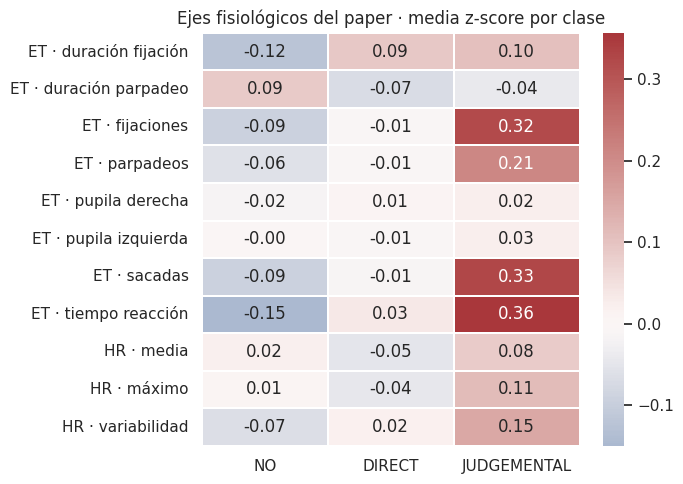

/tmp/ipykernel_150704/1559919854.py:126: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_150704/1559919854.py:126: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_150704/1559919854.py:126: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_150704/1559919854.py:126: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_150704/1559919854.py:126: Fut

/tmp/ipykernel_150704/1559919854.py:126: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_150704/1559919854.py:126: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Guardado: /home/sortmon/LNR_CHG/EXIST2026_MEMES_ONLY_FINAL/outputs/figures/task2_2_sexist_only_eda/12c_paper_sensor_axis_boxplots.png


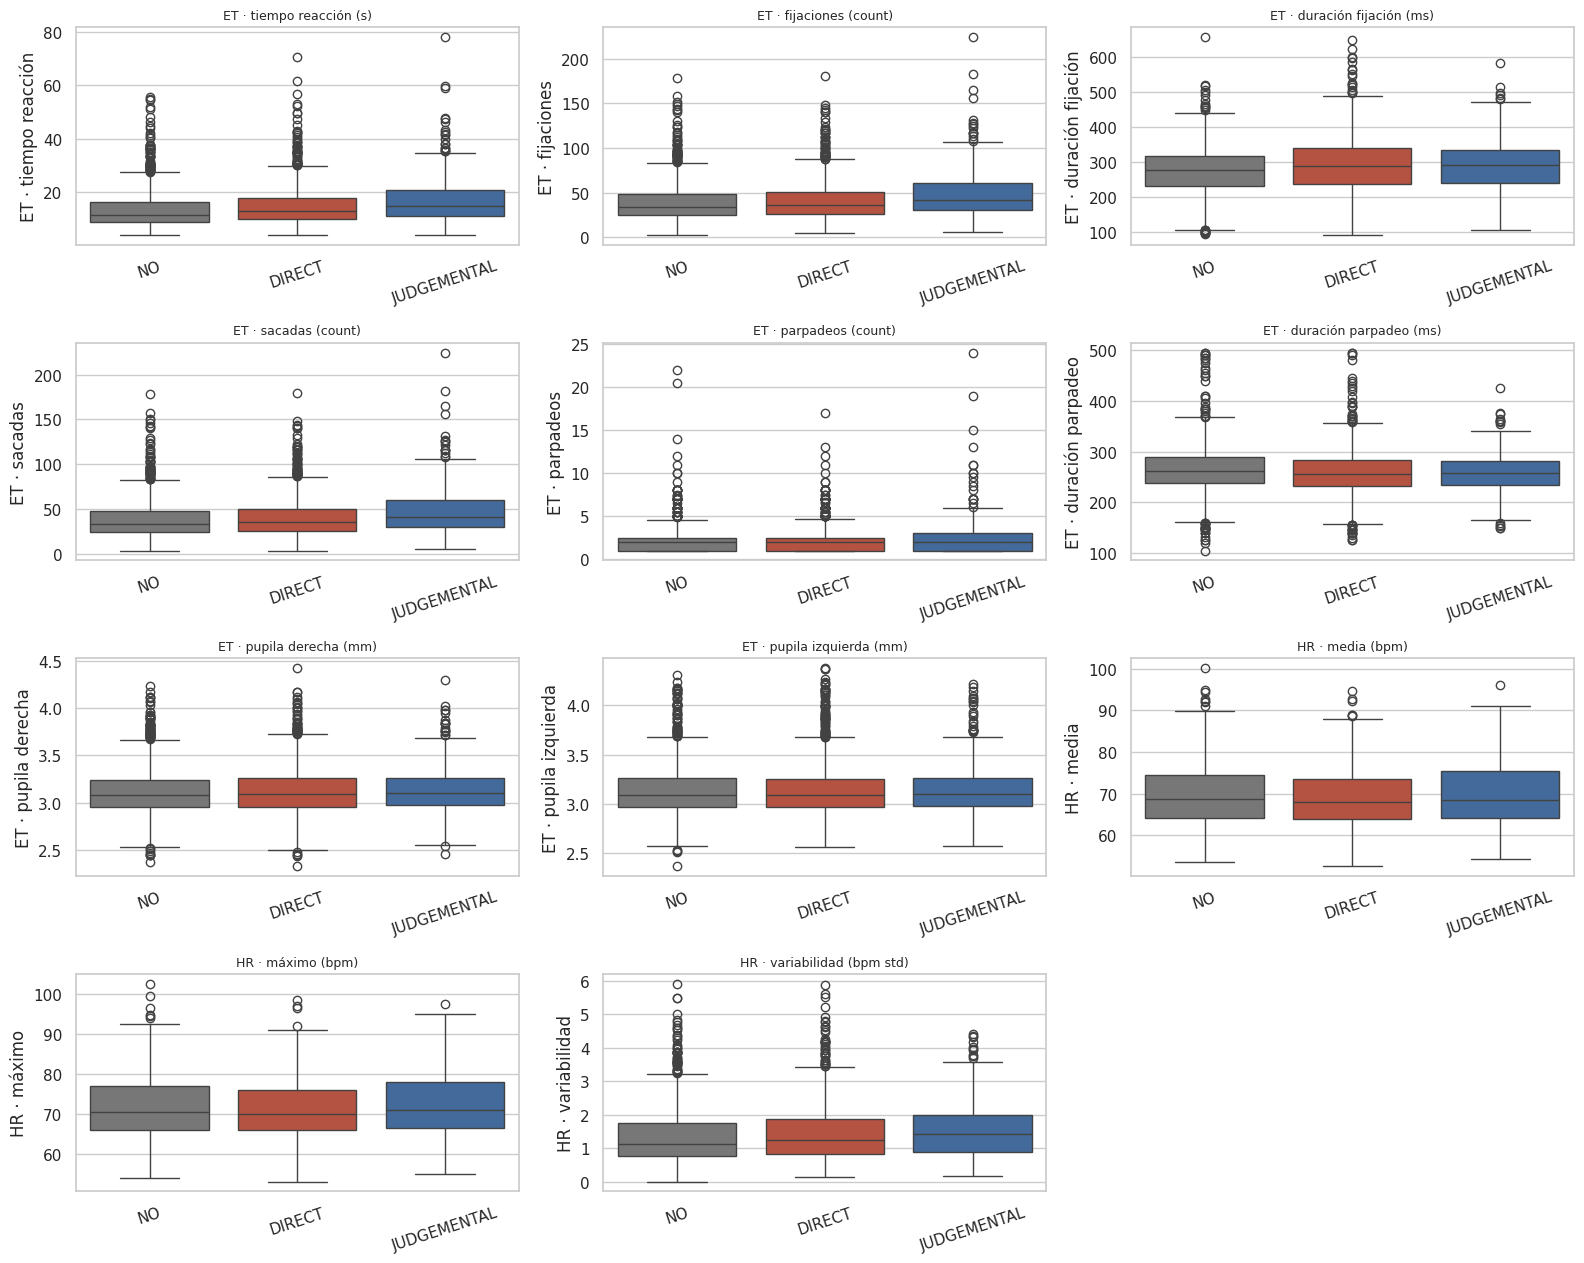

In [11]:
from scipy.stats import mannwhitneyu


def bh_adjust(p_values):
    p = np.asarray(p_values, dtype=float)
    adjusted = np.full(p.shape, np.nan, dtype=float)
    valid = np.isfinite(p)
    if not valid.any():
        return adjusted
    valid_idx = np.where(valid)[0]
    order = valid_idx[np.argsort(p[valid])]
    ranked = p[order] * len(order) / np.arange(1, len(order) + 1)
    ranked = np.minimum.accumulate(ranked[::-1])[::-1]
    adjusted[order] = np.clip(ranked, 0, 1)
    return adjusted


def mannwhitney_row(frame, col, label):
    direct = pd.to_numeric(frame.loc[frame["gold"] == "DIRECT", col], errors="coerce").dropna().to_numpy(dtype=float)
    judgemental = pd.to_numeric(frame.loc[frame["gold"] == "JUDGEMENTAL", col], errors="coerce").dropna().to_numpy(dtype=float)
    if len(direct) < 5 or len(judgemental) < 5:
        return None
    pooled = math.sqrt((np.nanvar(direct) + np.nanvar(judgemental)) / 2.0)
    d_value = 0.0 if pooled == 0 else (np.nanmean(direct) - np.nanmean(judgemental)) / pooled
    stat, p_value = mannwhitneyu(direct, judgemental, alternative="two-sided")
    return {
        "axis": label,
        "direct_n": len(direct),
        "judgemental_n": len(judgemental),
        "direct_mean": float(np.nanmean(direct)),
        "judgemental_mean": float(np.nanmean(judgemental)),
        "direct_median": float(np.nanmedian(direct)),
        "judgemental_median": float(np.nanmedian(judgemental)),
        "cohen_d_direct_minus_judgemental": float(d_value),
        "abs_d": abs(float(d_value)),
        "mannwhitney_u": float(stat),
        "p_value": float(p_value),
        "direction": "DIRECT > JUDGEMENTAL" if d_value > 0 else "JUDGEMENTAL > DIRECT",
    }


paper_axis_specs = [
    ("ET · tiempo reacción", "sens_ET_reaction_time_mean", 1 / 1000, "s", "ET_reaction"),
    ("ET · fijaciones", "sens_ET_fixations_count_mean", 1, "count", "ET_fixations"),
    ("ET · duración fijación", "sens_ET_fixations_duration_mean_ns_mean", 1 / 1_000_000, "ms", "ET_fixations"),
    ("ET · sacadas", "sens_ET_saccades_count_mean", 1, "count", "ET_saccades"),
    ("ET · parpadeos", "sens_ET_blinks_count_mean", 1, "count", "ET_blinks"),
    ("ET · duración parpadeo", "sens_ET_blinks_duration_mean_ns_mean", 1 / 1_000_000, "ms", "ET_blinks"),
    ("ET · pupila derecha", "sens_ET_3d_eye_states_pupil_diameter_right_mm_mean_mean", 1, "mm", "ET_pupil"),
    ("ET · pupila izquierda", "sens_ET_3d_eye_states_pupil_diameter_left_mm_mean_mean", 1, "mm", "ET_pupil"),
    ("HR · media", "sens_HR_garmin_hr_mean_mean", 1, "bpm", "HR"),
    ("HR · máximo", "sens_HR_garmin_hr_max_mean", 1, "bpm", "HR"),
    ("HR · variabilidad", "sens_HR_garmin_hr_std_mean", 1, "bpm std", "HR"),
]

paper_sensor = official_task22[["id", "lang", "gold"]].copy()
paper_axis_meta = []
for axis, col, scale, unit, family in paper_axis_specs:
    if col in official_task22.columns:
        paper_sensor[axis] = pd.to_numeric(official_task22[col], errors="coerce") * scale
        paper_axis_meta.append({"axis": axis, "source_feature": col, "unit": unit, "family": family})

paper_axis_meta = pd.DataFrame(paper_axis_meta)
axis_cols = paper_axis_meta["axis"].tolist()

paper_sensor_long = paper_sensor.melt(
    id_vars=["id", "lang", "gold"],
    value_vars=axis_cols,
    var_name="axis",
    value_name="value",
).merge(paper_axis_meta, on="axis", how="left")

paper_axis_summary = (
    paper_sensor_long.dropna(subset=["value"])
    .groupby(["gold", "axis", "family", "unit"])["value"]
    .agg(n="count", mean="mean", median="median", std="std")
    .reset_index()
)
paper_axis_summary["gold"] = pd.Categorical(paper_axis_summary["gold"], ["NO", "DIRECT", "JUDGEMENTAL"], ordered=True)
paper_axis_summary = paper_axis_summary.sort_values(["axis", "gold"]).reset_index(drop=True)
save_table(paper_axis_summary, "task2_2_sexist_only_eda_paper_sensor_axis_summary.csv")
display(paper_axis_summary.head(18))

paper_axis_tests = []
for axis in axis_cols:
    row = mannwhitney_row(paper_sensor, axis, axis)
    if row:
        paper_axis_tests.append(row)
paper_axis_tests = pd.DataFrame(paper_axis_tests)
if not paper_axis_tests.empty:
    paper_axis_tests["bh_p_value"] = bh_adjust(paper_axis_tests["p_value"].to_numpy())
    paper_axis_tests = paper_axis_tests.sort_values("abs_d", ascending=False).reset_index(drop=True)
save_table(paper_axis_tests, "task2_2_sexist_only_eda_paper_sensor_axis_tests.csv")
display(paper_axis_tests)

baseline_cols = [col for col in sensor_cols if re.search(r"baseline|prev", col, flags=re.IGNORECASE)]
sensor_baseline_audit = pd.DataFrame([
    {
        "sensor_features_total": len(sensor_cols),
        "baseline_like_features_found": len(baseline_cols),
        "baseline_like_feature_examples": "; ".join(baseline_cols[:12]),
        "eda_decision": "usar baselines si existen" if baseline_cols else "no hay columnas baseline/prev en el feature frame; no se asume normalizacion baseline_prev/baseline_prev5",
    }
])
save_table(sensor_baseline_audit, "task2_2_sexist_only_eda_sensor_baseline_audit.csv")
display(sensor_baseline_audit)

if axis_cols:
    axis_z = paper_sensor_long.dropna(subset=["value"]).copy()
    axis_z["z"] = axis_z.groupby("axis")["value"].transform(lambda s: (s - s.mean()) / (s.std(ddof=0) if s.std(ddof=0) else 1))
    axis_z_means = axis_z.groupby(["axis", "gold"])["z"].mean().unstack()
    axis_z_means = axis_z_means.reindex(columns=["NO", "DIRECT", "JUDGEMENTAL"])
    fig, ax = plt.subplots(figsize=(7, max(5, 0.42 * len(axis_z_means))))
    sns.heatmap(axis_z_means, cmap="vlag", center=0, annot=True, fmt=".2f", linewidths=0.2, ax=ax)
    ax.set_title("Ejes fisiológicos del paper · media z-score por clase")
    ax.set_xlabel("")
    ax.set_ylabel("")
    savefig("12b_paper_sensor_axes_zscore.png")
    plt.show()

    n_cols = 3
    n_rows = math.ceil(len(axis_cols) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, max(4, 3.2 * n_rows)))
    axes = np.asarray(axes).ravel()
    for ax, axis in zip(axes, axis_cols):
        sns.boxplot(
            data=paper_sensor,
            x="gold",
            y=axis,
            order=["NO", "DIRECT", "JUDGEMENTAL"],
            palette=[palette["NO"], palette["DIRECT"], palette["JUDGEMENTAL"]],
            ax=ax,
        )
        unit = paper_axis_meta.loc[paper_axis_meta["axis"] == axis, "unit"].iloc[0]
        ax.set_title(f"{axis} ({unit})", fontsize=9)
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=18)
    for ax in axes[len(axis_cols):]:
        ax.axis("off")
    savefig("12c_paper_sensor_axis_boxplots.png")
    plt.show()


### 6.2. ET/HR families and EEG bands

Signals are summarized by physiological family and EEG is inspected by band and channel. Because this release does not provide an anatomical channel map, channels remain named `EXG_Channel_*`; no brain-region interpretation is inferred.

Guardado: /home/sortmon/LNR_CHG/EXIST2026_MEMES_ONLY_FINAL/outputs/tables/task2_2_sexist_only_eda_sensor_family_effects.csv


,modality,family,n_features,mean_abs_d,max_abs_d,best_feature,best_direction,best_d,best_direct_mean,best_judgemental_mean
0,ET,ET_saccades,10,0.187787,0.315192,sens_ET_saccades_count_mean,JUDGEMENTAL > DIRECT,-0.315192,40.553127,48.203826
1,ET,ET_fixations,10,0.089347,0.306628,sens_ET_fixations_count_mean,JUDGEMENTAL > DIRECT,-0.306628,41.379236,48.805817
2,ET,ET_reaction_time,2,0.264893,0.300379,sens_ET_reaction_time_mean,JUDGEMENTAL > DIRECT,-0.300379,14778.360464,17190.266762
3,ET,ET_blinks,10,0.061509,0.190926,sens_ET_blinks_count_mean,JUDGEMENTAL > DIRECT,-0.190926,2.208953,2.592334
4,HR,HR_garmin,9,0.124837,0.173513,sens_HR_garmin_hr_mean_std,JUDGEMENTAL > DIRECT,-0.173513,6.908196,7.837842
5,EEG,EEG_Delta,32,0.052867,0.162655,sens_EEG_EXG_Channel_0_Delta_power_mean,JUDGEMENTAL > DIRECT,-0.162655,-0.115580,0.008069
6,EEG,EEG_Theta,32,0.056475,0.162484,sens_EEG_EXG_Channel_0_Theta_power_mean,JUDGEMENTAL > DIRECT,-0.162484,-0.093372,0.036829
7,EEG,EEG_Gamma,32,0.049966,0.157076,sens_EEG_EXG_Channel_0_Gamma_power_std,DIRECT > JUDGEMENTAL,0.157076,0.626970,0.537421
8,EEG,EEG_Beta,32,0.049530,0.153860,sens_EEG_EXG_Channel_14_Beta_power_std,DIRECT > JUDGEMENTAL,0.153860,0.624851,0.548292
9,EEG,EEG_Alpha,32,0.049735,0.136279,sens_EEG_EXG_Channel_14_Alpha_power_std,DIRECT > JUDGEMENTAL,0.136279,0.871196,0.772341


Guardado: /home/sortmon/LNR_CHG/EXIST2026_MEMES_ONLY_FINAL/outputs/figures/task2_2_sexist_only_eda/12d_sensor_family_effects.png


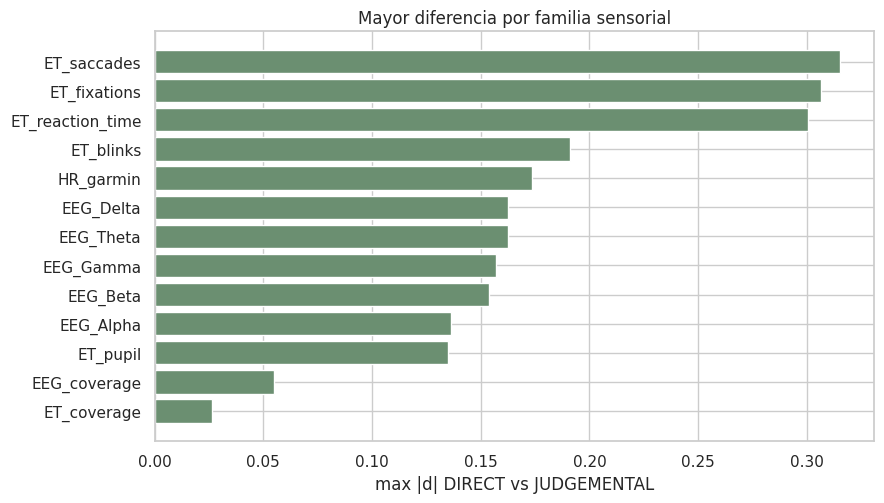

Guardado: /home/sortmon/LNR_CHG/EXIST2026_MEMES_ONLY_FINAL/outputs/tables/task2_2_sexist_only_eda_eeg_band_channel_effects.csv


,axis,direct_n,judgemental_n,direct_mean,judgemental_mean,direct_median,judgemental_median,cohen_d_direct_minus_judgemental,abs_d,mannwhitney_u,p_value,direction,channel,band,feature,bh_p_value
0,sens_EEG_EXG_Channel_0_Delta_power_mean,1338,444,-0.115580,0.008069,-0.072375,0.027325,-0.162655,0.162655,267084.5,0.001433,JUDGEMENTAL > DIRECT,0,Delta,sens_EEG_EXG_Channel_0_Delta_power_mean,0.057321
1,sens_EEG_EXG_Channel_0_Theta_power_mean,1338,444,-0.093372,0.036829,-0.045175,0.059700,-0.162484,0.162484,265580.5,0.000814,JUDGEMENTAL > DIRECT,0,Theta,sens_EEG_EXG_Channel_0_Theta_power_mean,0.057321
2,sens_EEG_EXG_Channel_8_Delta_power_mean,1338,444,0.206961,0.313857,0.010250,0.085900,-0.137499,0.137499,271806.0,0.007245,JUDGEMENTAL > DIRECT,8,Delta,sens_EEG_EXG_Channel_8_Delta_power_mean,0.144899
3,sens_EEG_EXG_Channel_8_Theta_power_mean,1338,444,0.217765,0.319353,0.063508,0.169025,-0.137070,0.137070,270948.5,0.005492,JUDGEMENTAL > DIRECT,8,Theta,sens_EEG_EXG_Channel_8_Theta_power_mean,0.144899
4,sens_EEG_EXG_Channel_5_Beta_power_mean,1338,444,-0.145423,-0.244809,-0.009375,-0.083200,0.120232,0.120232,315117.5,0.054292,DIRECT > JUDGEMENTAL,5,Beta,sens_EEG_EXG_Channel_5_Beta_power_mean,0.542920
5,sens_EEG_EXG_Channel_5_Gamma_power_mean,1338,444,-0.263543,-0.361338,-0.090425,-0.151250,0.119948,0.119948,315438.5,0.050152,DIRECT > JUDGEMENTAL,5,Gamma,sens_EEG_EXG_Channel_5_Gamma_power_mean,0.542920
6,sens_EEG_EXG_Channel_2_Delta_power_mean,1338,444,0.183672,0.039117,0.112975,0.037225,0.114287,0.114287,320152.0,0.013880,DIRECT > JUDGEMENTAL,2,Delta,sens_EEG_EXG_Channel_2_Delta_power_mean,0.222076
7,sens_EEG_EXG_Channel_5_Alpha_power_mean,1338,444,-0.110281,-0.240868,0.021175,-0.018350,0.110668,0.110668,310720.5,0.145256,DIRECT > JUDGEMENTAL,5,Alpha,sens_EEG_EXG_Channel_5_Alpha_power_mean,0.725402
8,sens_EEG_EXG_Channel_5_Delta_power_mean,1338,444,0.135259,0.003541,0.083700,0.073525,0.106729,0.106729,308329.0,0.229384,DIRECT > JUDGEMENTAL,5,Delta,sens_EEG_EXG_Channel_5_Delta_power_mean,0.739144
9,sens_EEG_EXG_Channel_5_Theta_power_mean,1338,444,-0.001037,-0.133878,0.024375,0.036900,0.105827,0.105827,306943.0,0.291688,DIRECT > JUDGEMENTAL,5,Theta,sens_EEG_EXG_Channel_5_Theta_power_mean,0.739144


Guardado: /home/sortmon/LNR_CHG/EXIST2026_MEMES_ONLY_FINAL/outputs/tables/task2_2_sexist_only_eda_eeg_band_summary.csv


,band,n_channels,mean_abs_d,max_abs_d,direct_higher_channels,judgemental_higher_channels,min_bh_p_value
2,Delta,16,0.064263,0.162655,7,9,0.057321
4,Theta,16,0.062729,0.162484,6,10,0.057321
0,Alpha,16,0.051036,0.110668,7,9,0.417837
1,Beta,16,0.044503,0.120232,11,5,0.542920
3,Gamma,16,0.041245,0.119948,10,6,0.542920


Guardado: /home/sortmon/LNR_CHG/EXIST2026_MEMES_ONLY_FINAL/outputs/figures/task2_2_sexist_only_eda/12e_eeg_band_channel_heatmap.png


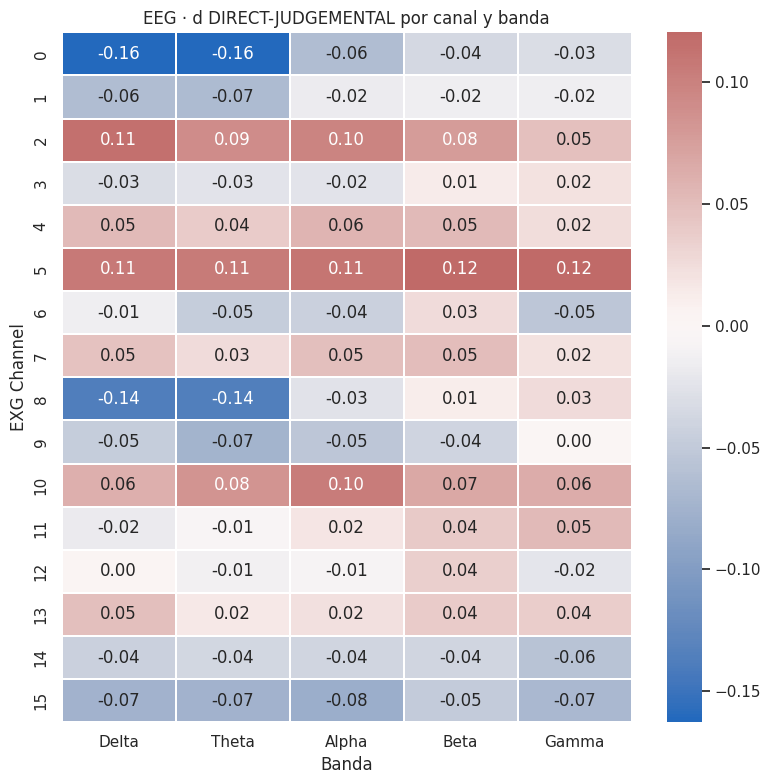

In [12]:
def sensor_feature_family(feature):
    if feature.startswith("sens_ET_"):
        lowered = feature.lower()
        if "reaction_time" in lowered:
            return "ET_reaction_time"
        if "fixations" in lowered:
            return "ET_fixations"
        if "saccades" in lowered:
            return "ET_saccades"
        if "blinks" in lowered:
            return "ET_blinks"
        if "pupil" in lowered:
            return "ET_pupil"
        if "users_count" in lowered:
            return "ET_coverage"
        return "ET_other"
    if feature.startswith("sens_HR_"):
        return "HR_garmin"
    if feature.startswith("sens_EEG_"):
        band_match = re.search(r"_(Delta|Theta|Alpha|Beta|Gamma)_power_", feature)
        if band_match:
            return f"EEG_{band_match.group(1)}"
        if "users_count" in feature:
            return "EEG_coverage"
        return "EEG_time_domain"
    return "sensor_other"

sensor_family_rows = []
if not sensor_effects.empty:
    sensor_effects_family = sensor_effects.assign(family=sensor_effects["feature"].map(sensor_feature_family))
    for (modality, family), group in sensor_effects_family.groupby(["modality", "family"]):
        best = group.sort_values("abs_d", ascending=False).iloc[0]
        sensor_family_rows.append({
            "modality": modality,
            "family": family,
            "n_features": int(len(group)),
            "mean_abs_d": float(group["abs_d"].mean()),
            "max_abs_d": float(group["abs_d"].max()),
            "best_feature": best["feature"],
            "best_direction": "DIRECT > JUDGEMENTAL" if best["cohen_d_direct_minus_judgemental"] > 0 else "JUDGEMENTAL > DIRECT",
            "best_d": float(best["cohen_d_direct_minus_judgemental"]),
            "best_direct_mean": float(best["direct_mean"]),
            "best_judgemental_mean": float(best["judgemental_mean"]),
        })
sensor_family_effects = pd.DataFrame(sensor_family_rows).sort_values("max_abs_d", ascending=False).reset_index(drop=True)
save_table(sensor_family_effects, "task2_2_sexist_only_eda_sensor_family_effects.csv")
display(sensor_family_effects)

if not sensor_family_effects.empty:
    top_families = sensor_family_effects.head(18).iloc[::-1]
    fig, ax = plt.subplots(figsize=(9, max(5, 0.4 * len(top_families))))
    ax.barh(top_families["family"], top_families["max_abs_d"], color="#6b8f71")
    ax.set_title("Mayor diferencia por familia sensorial")
    ax.set_xlabel("max |d| DIRECT vs JUDGEMENTAL")
    savefig("12d_sensor_family_effects.png")
    plt.show()

# EEG por bandas y canales, usando la media de potencia por meme y usuario agregado.
eeg_pattern = re.compile(r"^sens_EEG_EXG_Channel_(\d+)_(Delta|Theta|Alpha|Beta|Gamma)_power_mean$")
eeg_band_rows = []
for col in eeg_cols:
    match = eeg_pattern.match(col)
    if not match:
        continue
    channel = int(match.group(1))
    band = match.group(2)
    row = mannwhitney_row(sexist_df, col, col)
    if row is None:
        continue
    row.update({"channel": channel, "band": band, "feature": col})
    eeg_band_rows.append(row)

eeg_band_channel_effects = pd.DataFrame(eeg_band_rows)
if not eeg_band_channel_effects.empty:
    eeg_band_channel_effects["bh_p_value"] = bh_adjust(eeg_band_channel_effects["p_value"].to_numpy())
    eeg_band_channel_effects = eeg_band_channel_effects.sort_values(["abs_d", "channel", "band"], ascending=[False, True, True]).reset_index(drop=True)
save_table(eeg_band_channel_effects, "task2_2_sexist_only_eda_eeg_band_channel_effects.csv")
display(eeg_band_channel_effects.head(25))

if not eeg_band_channel_effects.empty:
    eeg_band_summary = (
        eeg_band_channel_effects.groupby("band")
        .agg(
            n_channels=("channel", "nunique"),
            mean_abs_d=("abs_d", "mean"),
            max_abs_d=("abs_d", "max"),
            direct_higher_channels=("cohen_d_direct_minus_judgemental", lambda s: int((s > 0).sum())),
            judgemental_higher_channels=("cohen_d_direct_minus_judgemental", lambda s: int((s < 0).sum())),
            min_bh_p_value=("bh_p_value", "min"),
        )
        .reset_index()
        .sort_values("mean_abs_d", ascending=False)
    )
    save_table(eeg_band_summary, "task2_2_sexist_only_eda_eeg_band_summary.csv")
    display(eeg_band_summary)

    band_order = ["Delta", "Theta", "Alpha", "Beta", "Gamma"]
    eeg_heat = eeg_band_channel_effects.pivot(index="channel", columns="band", values="cohen_d_direct_minus_judgemental")
    eeg_heat = eeg_heat.reindex(columns=band_order)
    fig, ax = plt.subplots(figsize=(8, 8))
    sns.heatmap(eeg_heat, cmap="vlag", center=0, annot=True, fmt=".2f", linewidths=0.2, ax=ax)
    ax.set_title("EEG · d DIRECT-JUDGEMENTAL por canal y banda")
    ax.set_xlabel("Banda")
    ax.set_ylabel("EXG Channel")
    savefig("12e_eeg_band_channel_heatmap.png")
    plt.show()


Guardado: /home/sortmon/LNR_CHG/EXIST2026_MEMES_ONLY_FINAL/outputs/figures/task2_2_sexist_only_eda/13_sensor_pca.png


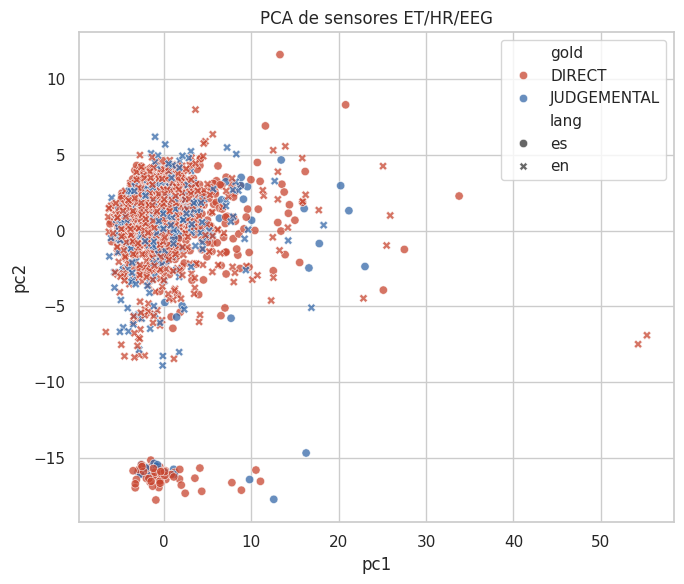

Guardado: /home/sortmon/LNR_CHG/EXIST2026_MEMES_ONLY_FINAL/outputs/figures/task2_2_sexist_only_eda/14_sensor_zscore_heatmap.png


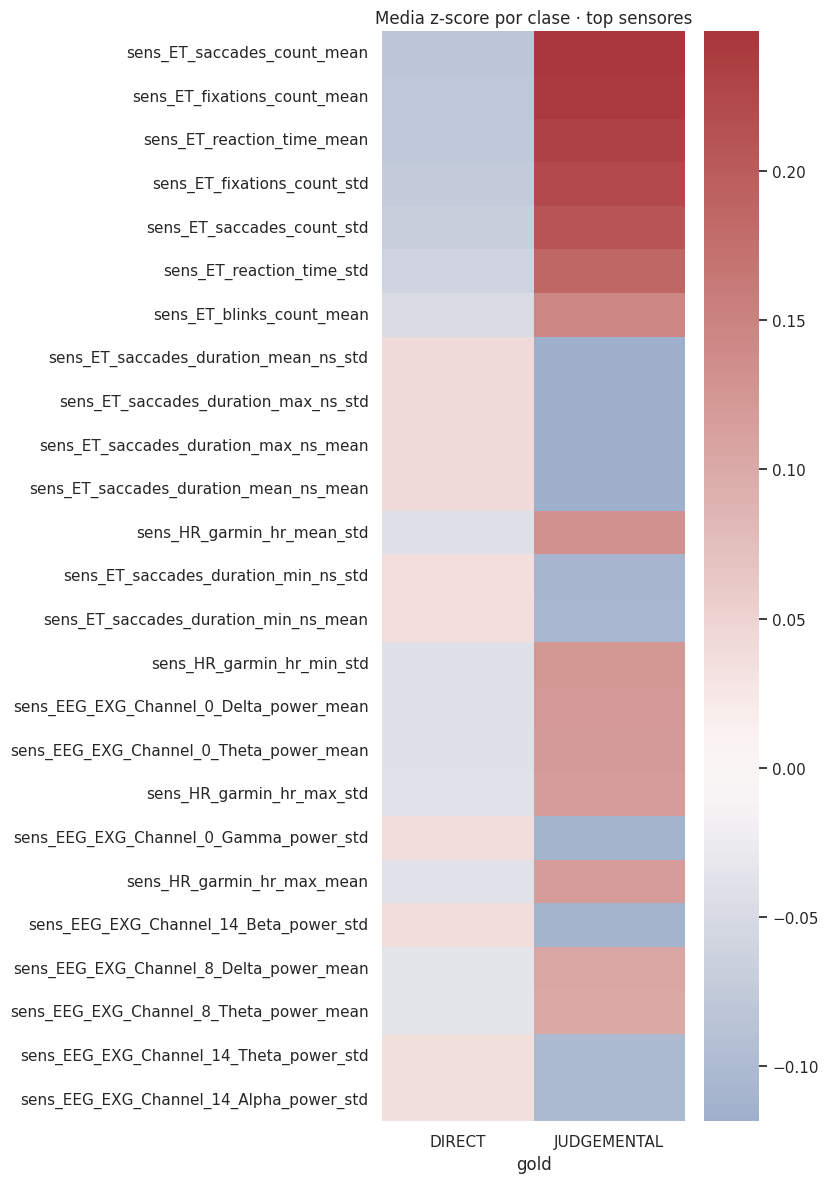

In [13]:
# PCA de sensores: útil para ver si hay separación global o solo micro-señales dispersas.
if len(sensor_cols) >= 2:
    X_sens = SimpleImputer(strategy="median").fit_transform(sexist_df[sensor_cols])
    X_sens = StandardScaler().fit_transform(X_sens)
    pcs = PCA(n_components=2, random_state=SEED).fit_transform(X_sens)
    pca_sens = pd.DataFrame({"pc1": pcs[:, 0], "pc2": pcs[:, 1], "gold": sexist_df["gold"], "lang": sexist_df["lang"]})
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.scatterplot(data=pca_sens, x="pc1", y="pc2", hue="gold", style="lang", palette={"DIRECT": palette["DIRECT"], "JUDGEMENTAL": palette["JUDGEMENTAL"]}, alpha=0.75, ax=ax)
    ax.set_title("PCA de sensores ET/HR/EEG")
    savefig("13_sensor_pca.png")
    plt.show()

# Mapa compacto de medias z-score para las features sensoriales más diferenciales.
heat_features = sensor_effects.head(25)["feature"].tolist()
heat = sexist_df[["gold"] + heat_features].copy()
X = SimpleImputer(strategy="median").fit_transform(heat[heat_features])
X = StandardScaler().fit_transform(X)
heat_z = pd.DataFrame(X, columns=heat_features)
heat_z["gold"] = sexist_df["gold"].to_numpy()
heat_means = heat_z.groupby("gold")[heat_features].mean().T
fig, ax = plt.subplots(figsize=(8, 12))
sns.heatmap(heat_means, cmap="vlag", center=0, ax=ax)
ax.set_title("Media z-score por clase · top sensores")
ax.set_ylabel("")
savefig("14_sensor_zscore_heatmap.png")
plt.show()

## 7. Cross-modal relationships

This section combines the principal text, image, and sensor signals to distinguish redundant features from potentially complementary ones.

Guardado: /home/sortmon/LNR_CHG/EXIST2026_MEMES_ONLY_FINAL/outputs/figures/task2_2_sexist_only_eda/15_cross_modal_correlations.png


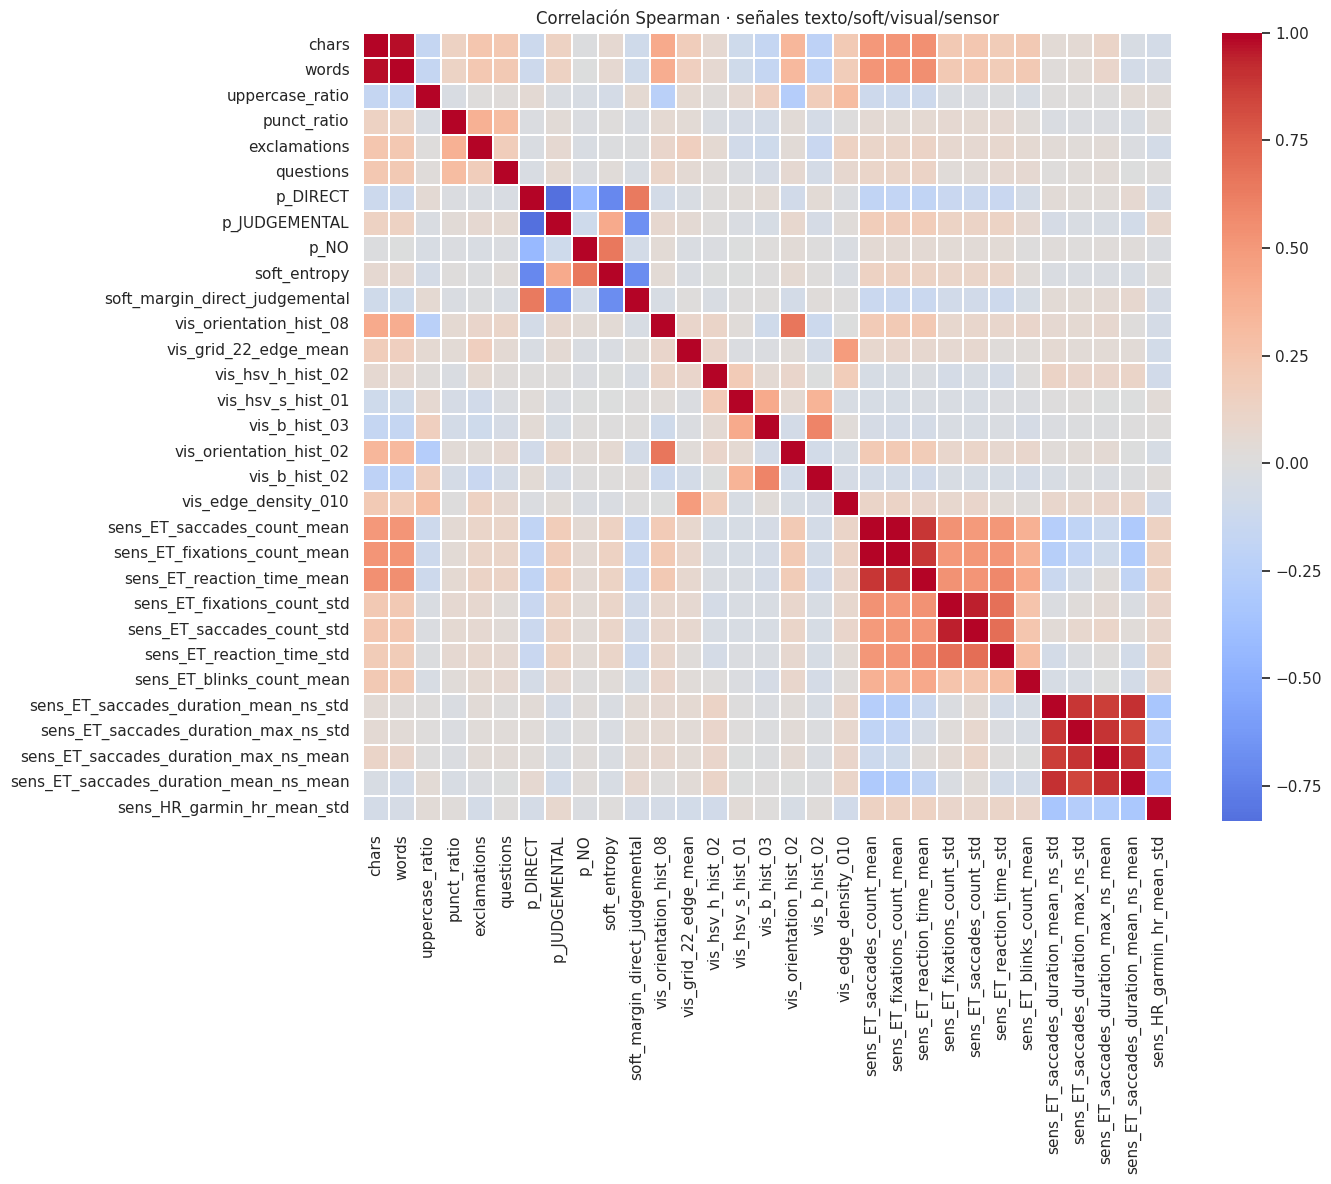

Guardado: /home/sortmon/LNR_CHG/EXIST2026_MEMES_ONLY_FINAL/outputs/tables/task2_2_sexist_only_eda_hypotheses.csv


,area,finding,modeling_option
0,metric,DIRECT es mayoritaria,"usar macro_f1, threshold tuning y reportar JUD..."
1,text,TF-IDF y términos chi2 muestran señal fuerte,mantener modelos clásicos como expertos de alt...
2,soft_labels,hay ejemplos con margen bajo,analizar errores en casos ambiguos y evitar op...
3,visual,rasgos visuales tienen señal débil/moderada,"usarlos como experto auxiliar, no como único m..."
4,sensors,ET/HR/EEG aportan micro-señales dispersas,fusion tardía/stacking o ramas pequeñas normal...
5,vlm,la intención puede depender de contradicción i...,generar razonamientos/captions y reentrenar ex...


In [14]:
cross = sexist_df[["id", "lang", "gold"]].copy()
cross = cross.merge(text_eda[["id", "chars", "words", "uppercase_ratio", "punct_ratio", "exclamations", "questions"]], on="id", how="left")
cross = cross.merge(soft_df[["id", "p_DIRECT", "p_JUDGEMENTAL", "p_NO", "soft_entropy", "soft_margin_direct_judgemental"]], on="id", how="left")
for col in visual_effects.head(8)["feature"].tolist() + sensor_effects.head(12)["feature"].tolist():
    cross[col] = sexist_df[col].to_numpy()

numeric_cross = [col for col in cross.columns if col not in {"id", "lang", "gold"}]
corr_data = pd.DataFrame(SimpleImputer(strategy="median").fit_transform(cross[numeric_cross]), columns=numeric_cross)
corr = corr_data.corr(method="spearman")
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax, linewidths=0.2)
ax.set_title("Correlación Spearman · señales texto/soft/visual/sensor")
savefig("15_cross_modal_correlations.png")
plt.show()

# Tabla resumen de pistas para modelado.
hypotheses = pd.DataFrame([
    {"area": "metric", "finding": "DIRECT es mayoritaria", "modeling_option": "usar macro_f1, threshold tuning y reportar JUDGEMENTAL F1"},
    {"area": "text", "finding": "TF-IDF y términos chi2 muestran señal fuerte", "modeling_option": "mantener modelos clásicos como expertos de alto peso"},
    {"area": "soft_labels", "finding": "hay ejemplos con margen bajo", "modeling_option": "analizar errores en casos ambiguos y evitar optimizar solo accuracy"},
    {"area": "visual", "finding": "rasgos visuales tienen señal débil/moderada", "modeling_option": "usarlos como experto auxiliar, no como único modelo"},
    {"area": "sensors", "finding": "ET/HR/EEG aportan micro-señales dispersas", "modeling_option": "fusion tardía/stacking o ramas pequeñas normalizadas"},
    {"area": "vlm", "finding": "la intención puede depender de contradicción imagen-texto", "modeling_option": "generar razonamientos/captions y reentrenar experto textual"},
])
save_table(hypotheses, "task2_2_sexist_only_eda_hypotheses.csv")
display(hypotheses)

## 8. Takeaways

- Macro-F1 is the primary metric because `DIRECT` dominates the conditional subset.
- OCR text provides the strongest base signal.
- Image and physiological features are best treated as complementary expert branches.
- ET/HR axes and EEG bands should remain interpretable and separately auditable.
- Missing baseline variables are not assumed or reconstructed.
- Sensor features require normalization and benefit from their own branch, feature selection, or a meta-model.
- Visual-language reasoning is particularly relevant to implicit judgement, sarcasm, and text-image contradiction.